# Do extreme weather events increase in frequency and/or in destructiveness over time?

# Task 1 – Exploratory NLP Analysis of Severe Weather Narratives

This task focuses on exploring and analysing severe weather reports collected by the United States National Weather Service (NWS). The objective is to better understand weather event patterns, damage distributions, and the relationship between textual narratives and severe weather impacts using Natural Language Processing (NLP) techniques.

The analysis includes:
- data exploration and preprocessing,
- damage distribution analysis,
- weather event frequency analysis,
- and later, NLP methods such as text normalization and TF-IDF analysis.

*Note: The dataset contains severe weather reports collected by the United States National Weather Service (NWS). Most events are associated with US states and regions, making the analysis geographically focused on weather hazards across the United States.

## 1. Data Loading and Exploration

In this section, the datasets were loaded and merged using the common `id` column. Initial exploration was performed to better understand:
- the structure of the data,
- available variables,
- weather event categories,
- textual narratives,
- and damage values.

Missing values were also identified and handled appropriately before further analysis.

In [3]:
# Module imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk

In [4]:
nltk.download("popular", quiet=True)

True

In [5]:
# Load datasets

train = pd.read_csv("train.csv")
additional_info = pd.read_csv("additional_info.csv")

In [6]:
# Dataset shapes

print("Train shape:", train.shape)
print("Additional info shape:", additional_info.shape)

Train shape: (785162, 5)
Additional info shape: (785162, 4)


In [7]:
# First rows of train dataset

train.head()

,id,event_type,episode_narrative,event_narrative,damage
0,347570,Flash Flood,Tropical Storm Lee formed from a persistent lo...,The Dade County Emergency Management Director ...,10000.0
1,1054380,Marine Thunderstorm Wind,Scattered thunderstorms moved across portions ...,A wind gust to 36 knots was measured at the Mo...,0.0
2,317977,Thunderstorm Wind,"During the evening hours on July 19th, a sever...",Numerous trees and power lines were downed acr...,50000.0
3,509299,High Wind,An upper-level trough moved through southern C...,The Big Black Mountain mesonet recorded a peak...,0.0
4,1009291,Hail,A small cluster of thunderstorms developed nor...,Quarter size hail fell near Rural.,0.0


In [8]:
# First rows of additional info dataset

additional_info.head()

,id,begin_date_time,cz_timezone,state
0,347570,05-SEP-11 14:30:00,EST-5,GEORGIA
1,1054380,20-SEP-22 17:19:00,CST-6,LAKE MICHIGAN
2,317977,19-JUL-11 22:45:00,EST-5,KENTUCKY
3,509299,26-APR-14 01:00:00,PST-8,CALIFORNIA
4,1009291,12-APR-22 16:16:00,CST-6,WISCONSIN


In [9]:
# Merge datasets

df = train.merge(additional_info, on="id", how="left")

print("Merged dataset shape:", df.shape)

df.head()

Merged dataset shape: (785162, 8)


,id,event_type,episode_narrative,event_narrative,damage,begin_date_time,cz_timezone,state
0,347570,Flash Flood,Tropical Storm Lee formed from a persistent lo...,The Dade County Emergency Management Director ...,10000.0,05-SEP-11 14:30:00,EST-5,GEORGIA
1,1054380,Marine Thunderstorm Wind,Scattered thunderstorms moved across portions ...,A wind gust to 36 knots was measured at the Mo...,0.0,20-SEP-22 17:19:00,CST-6,LAKE MICHIGAN
2,317977,Thunderstorm Wind,"During the evening hours on July 19th, a sever...",Numerous trees and power lines were downed acr...,50000.0,19-JUL-11 22:45:00,EST-5,KENTUCKY
3,509299,High Wind,An upper-level trough moved through southern C...,The Big Black Mountain mesonet recorded a peak...,0.0,26-APR-14 01:00:00,PST-8,CALIFORNIA
4,1009291,Hail,A small cluster of thunderstorms developed nor...,Quarter size hail fell near Rural.,0.0,12-APR-22 16:16:00,CST-6,WISCONSIN


In [10]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785162 entries, 0 to 785161
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 785162 non-null  int64  
 1   event_type         785162 non-null  object 
 2   episode_narrative  697152 non-null  object 
 3   event_narrative    694988 non-null  object 
 4   damage             785162 non-null  float64
 5   begin_date_time    785162 non-null  object 
 6   cz_timezone        785162 non-null  object 
 7   state              785161 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 47.9+ MB


Checking the difference between the content in `episode_narrative` and `event_narrative` columns. `episode_narrative` gives technical detail of the meteoreological episode - from its formation to its passage thru the area where the event occurred to its end farther in the future. `event_narrative` provides information of the impact of the meteorological episode in a locality, often with input from citizens or media outlets.

In [11]:
for col in df.head(n=1).iloc[0].items():
    print(col)

('id', np.int64(347570))
('event_type', 'Flash Flood')
('episode_narrative', 'Tropical Storm Lee formed from a persistent low pressure area off the upper Texas and Louisiana coasts on the south side of a mammoth subtropical ridge centered across the eastern Ohio valley.  This occurred during the late few days of August.  The system slowly intensified under weak steering currents and moved onshore the Louisiana coast on the 3rd.  Tropical Storm Lee was extremely slow moving at this point and consequently dumped excessive rainfall across southeast Louisiana.  A sharp upper trough began to take shape in the central U.S. on September 4th as upper energy dug southeast from Canada.  As this occurred, the remnants of Lee began to accelerate northeastward in association with the advancing upper trough.  The remnants of Lee traveled very quickly along the advancing front, racing across Georgia on the 5th.  Rain bands began to affect the area late on the 4th, but most of these were light to mode

In [12]:
# Handle missing values

# Replace missing text narratives with empty strings
# This avoids errors during text analysis

df["episode_narrative"] = df["episode_narrative"].fillna("")
df["event_narrative"] = df["event_narrative"].fillna("")

# Replace missing state values with "Unknown"
# This keeps the categorical information consistent

df["state"] = df["state"].fillna("Unknown")

# Check if there are any remaining missing values

df.isnull().sum()

id                   0
event_type           0
episode_narrative    0
event_narrative      0
damage               0
begin_date_time      0
cz_timezone          0
state                0
dtype: int64

## 2. Analysis of Weather Events and Economic Damage

This section explores the relationship between severe weather events and their economic impact across the United States.

The analysis focuses on:
- financial damage distribution,
- weather event frequency,
- damage by event type,
- and geographic patterns across states and territories.

The goal is to identify important trends and patterns before applying NLP and machine learning techniques.

### 2.1 Financial Damage Analysis

This subsection examines the distribution and severity of financial damage caused by severe weather events.

In [13]:
# Damage statistics

df["damage"].describe()

count    7.851620e+05
mean     2.093722e+05
std      7.275036e+06
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+03
max      9.400000e+08
Name: damage, dtype: float64

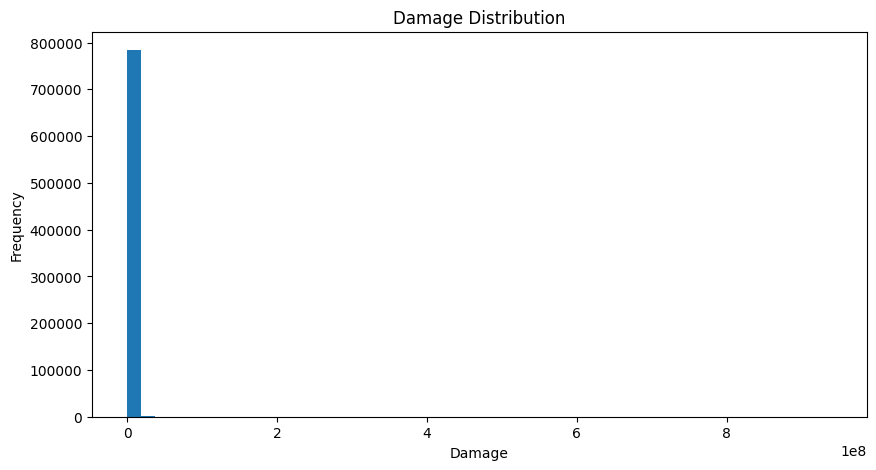

In [14]:
# Damage distribution

plt.figure(figsize=(10,5))

plt.hist(df["damage"], bins=50)

plt.title("Damage Distribution")
plt.xlabel("Damage")
plt.ylabel("Frequency")

plt.show()

**Interpretation of the Damage Distribution**

- The original damage distribution is extremely skewed to zero, with most weather events having caused little to no reported damage.
- A small number of extreme events produced exceptionally high losses, creating strong outliers in the dataset.
- Because of these outliers, the histogram becomes highly compressed, making it difficult to clearly observe the variation among lower and moderate damage values.
- Below, we log-transform our data - using `log(1+data)` due to large number of `data=0` entries.

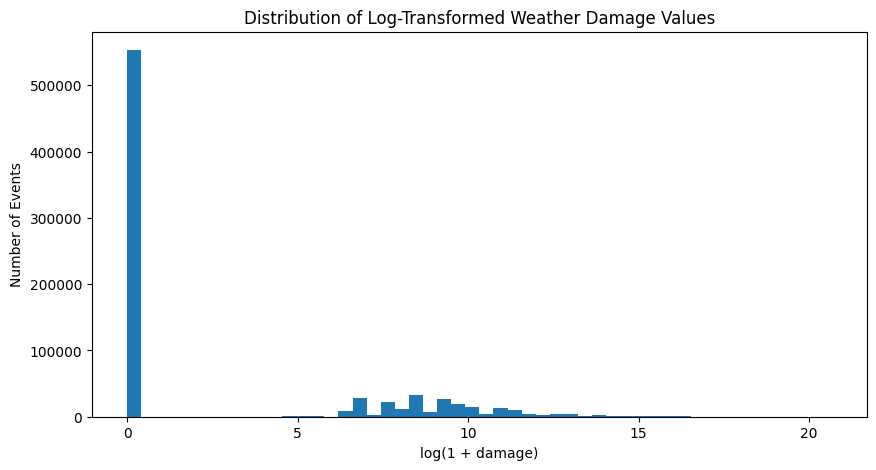

In [15]:
# Log-transformed distribution of all damage values

plt.figure(figsize=(10,5))

# Apply logarithmic transformation to damage values
log_damage = np.log1p(df["damage"])

# Plot histogram
plt.hist(log_damage, bins=50)

# Titles and labels
plt.title("Distribution of Log-Transformed Weather Damage Values")
plt.xlabel("log(1 + damage)")
plt.ylabel("Number of Events")

plt.show()

In [16]:
# Compare number of events and total financial damage

summary = pd.DataFrame({
    "Category": ["Zero-damage events", "Non-zero damage events"],
    "Number of Events": [
        (df["damage"] == 0).sum(),
        (df["damage"] > 0).sum()
    ],
    "Total Financial Damage": [
        df[df["damage"] == 0]["damage"].sum(),
        df[df["damage"] > 0]["damage"].sum()
    ]
})

summary

,Category,Number of Events,Total Financial Damage
0,Zero-damage events,553088,0.000000e+00
1,Non-zero damage events,232074,1.643911e+11


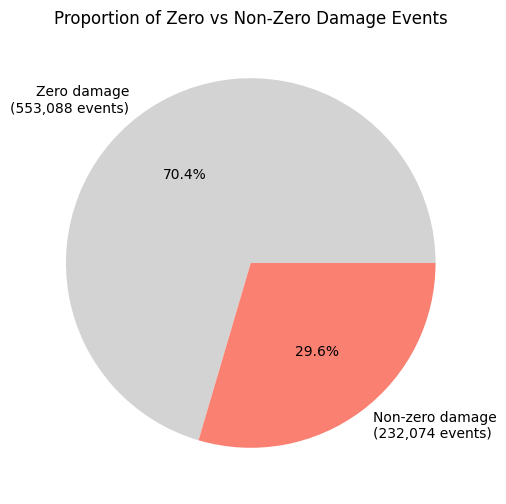

In [17]:
# Zero vs non-zero damage events

zero_damage = (df["damage"] == 0).sum()
non_zero_damage = (df["damage"] > 0).sum()

labels = [
    f"Zero damage\n({zero_damage:,} events)",
    f"Non-zero damage\n({non_zero_damage:,} events)"
]

sizes = [zero_damage, non_zero_damage]

# Gray for zero damage, red/orange for damaging events
colors = ["lightgray", "salmon"]

plt.figure(figsize=(6,6))

plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct="%1.1f%%"
)

plt.title("Proportion of Zero vs Non-Zero Damage Events")

plt.show()

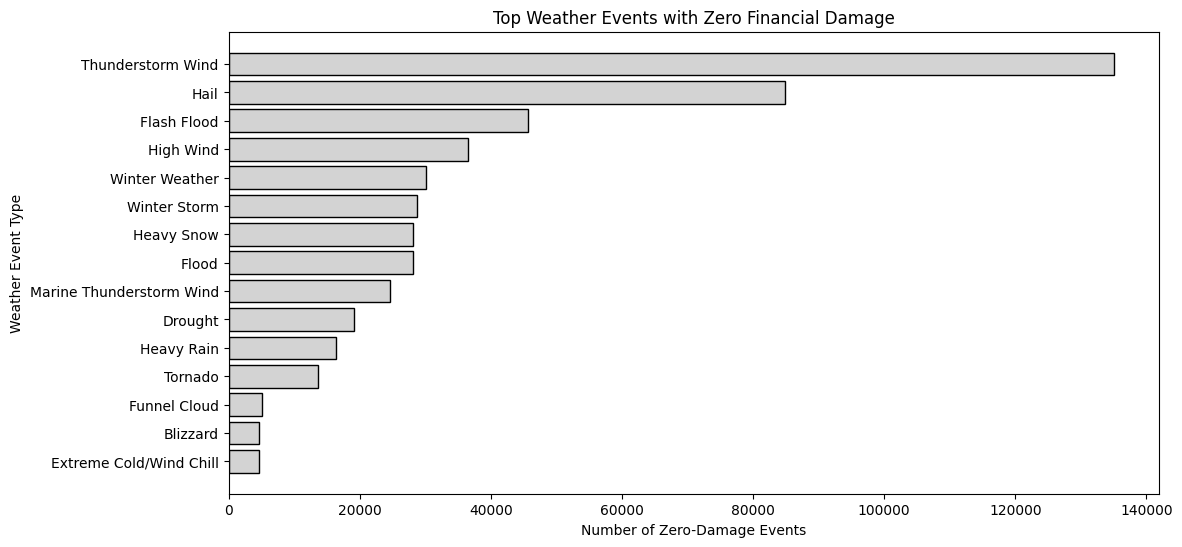

In [18]:
# Most common weather events with zero financial damage

zero_damage_events = (
    df[df["damage"] == 0]["event_type"]
    .value_counts()
    .head(15)
    .sort_values(ascending=True)
)

plt.figure(figsize=(12,6))

plt.barh(
    zero_damage_events.index,
    zero_damage_events.values,
    color="lightgray",
    edgecolor="black"
)

plt.title("Top Weather Events with Zero Financial Damage")
plt.xlabel("Number of Zero-Damage Events")
plt.ylabel("Weather Event Type")

plt.show()

In [19]:
# Remove zero-damage events

non_zero_damage = df[df["damage"] > 0]

#print(non_zero_damage.shape)
non_zero_damage.head()

,id,event_type,episode_narrative,event_narrative,damage,begin_date_time,cz_timezone,state
0,347570,Flash Flood,Tropical Storm Lee formed from a persistent lo...,The Dade County Emergency Management Director ...,10000.0,05-SEP-11 14:30:00,EST-5,GEORGIA
2,317977,Thunderstorm Wind,"During the evening hours on July 19th, a sever...",Numerous trees and power lines were downed acr...,50000.0,19-JUL-11 22:45:00,EST-5,KENTUCKY
9,310822,Hail,"A powerful, late season, low pressure system b...",Hail between 1.75 inches and 2 inches in diame...,50000.0,26-MAY-11 12:35:00,CST-6,MISSISSIPPI
10,136823,Hurricane (Typhoon),"Hurricane Gustav caused wind damage, flash flo...",Hurricane Gustav moved across Avoyelles Parish...,45000000.0,01-SEP-08 17:00:00,CST-6,LOUISIANA
21,119456,Thunderstorm Wind,Numerous thunderstorms developed across the re...,An intense downburst occurred in Wesson where ...,700000.0,25-JUN-08 12:34:00,CST-6,MISSISSIPPI


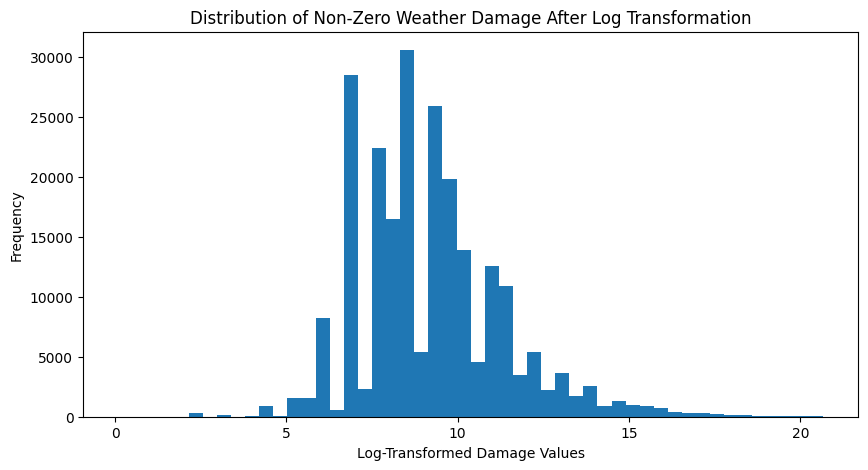

In [20]:
# Log-transformed non-zero damage distribution

plt.figure(figsize=(10,5))

plt.hist(np.log1p(non_zero_damage["damage"]), bins=50)

plt.title("Distribution of Non-Zero Weather Damage After Log Transformation")
plt.xlabel("Log-Transformed Damage Values")
plt.ylabel("Frequency")

plt.show()

**Interpretation of the Log-Transformed Damage Distribution**

The original damage distribution was heavily affected by extreme outliers and a large number of zero-damage events.  
After removing zero values and applying the logarithmic transformation using `log(1 + damage)`, the distribution became more balanced and easier to interpret.  
- Most weather events are associated with moderate levels of economic damage.  
- However, some severe events still cause exceptionally high financial losses, reflected by the remaining right-skewed tail of the distribution.  
- Overall, the transformed distribution highlights the considerable variability in the economic impact of severe weather events across the dataset.

### **Conclusion of Financial Damage Analysis**

The financial damage analysis shows that weather-related losses are highly unevenly distributed across events. Most recorded weather events cause little or no economic damage, while a relatively small number of extreme events generate exceptionally large losses.

The logarithmic transformation improved the interpretability of the damage distribution by reducing the influence of extreme outliers and revealing a more balanced pattern among non-zero damage values. Overall, the analysis confirms the presence of strong variability and right-skewness in economic damage caused by severe weather events.

### 2.2 Weather Event Frequency Analysis

This subsection explores the frequency and distribution of severe weather event types recorded in the dataset.


In [21]:
# Table of the most common weather events

top_events_table = (
    df["event_type"]
    .value_counts()
    .head(20)
    .reset_index()
)

# Rename columns
top_events_table.columns = ["Weather Event Type", "Number of Events"]

# Display table with title
print("Top 20 Most Frequent Weather Events")
display(top_events_table)

Top 20 Most Frequent Weather Events


,Weather Event Type,Number of Events
0,Thunderstorm Wind,268172
1,Hail,96930
2,Flash Flood,71018
3,High Wind,43401
4,Flood,38958
5,Winter Weather,31319
6,Winter Storm,30837
7,Heavy Snow,29224
8,Tornado,28283
9,Marine Thunderstorm Wind,24675


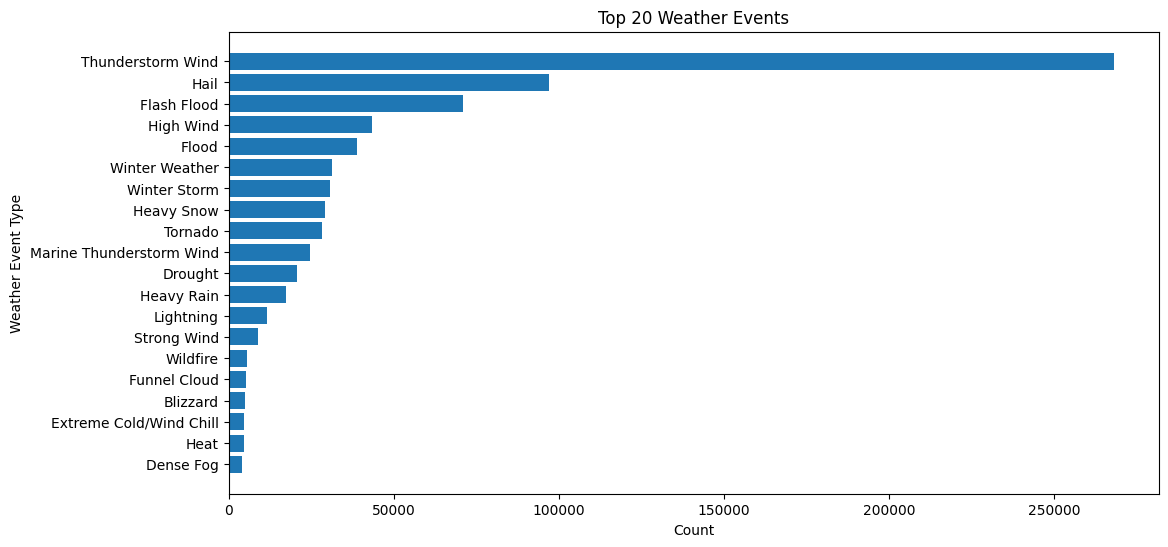

In [22]:
# Top 15 weather events

top_events = (
    df["event_type"]
    .value_counts()
    .head(20)
    .sort_values(ascending=True)
)

plt.figure(figsize=(12,6))

plt.barh(top_events.index, top_events.values)

plt.title("Top 20 Weather Events")
plt.xlabel("Count")
plt.ylabel("Weather Event Type")

plt.show()

**Interpretation of the Most Frequent Weather Events**

The analysis of event frequencies shows that **Thunderstorm Wind** is by far the most frequently recorded weather event in the dataset, followed by **Hail** and **Flash Flood** events.

These results describe how common each weather event type is, not how severe or economically damaging the events are. Therefore, highly frequent events are not necessarily the most destructive ones.

Other commonly reported events include:

- High Wind  
- Flood  
- Winter Weather  
- Winter Storm  
- Heavy Snow  

The results indicate that wind-related, precipitation-related, and winter-related hazards dominate severe weather reports across the United States.

In contrast, events such as **Wildfire**, **Strong Wind**, **Heat**, and **Dense Fog** occur less frequently within the top recorded categories.

Overall, the distribution demonstrates that weather hazards are not uniformly represented in the dataset, with a relatively small number of event types accounting for a large proportion of all severe weather reports. 

To better understand event severity, the next step is to analyse the average financial damage caused by each weather event type.

### **Conclusion of Weather Event Frequency Analysis**

The Weather Event Frequency Analysis shows that severe weather events are not equally represented within the dataset. Events such as **Thunderstorm Wind**, **Hail**, and **Flash Flood** occur far more frequently than other weather categories, indicating that wind- and precipitation-related hazards are the most commonly reported events.

However, the analysis also demonstrates that event frequency does not necessarily correspond to event severity. While some weather events occur very often, other less frequent events such as hurricanes, tropical storms, and tsunamis tend to produce substantially greater financial damage.

Overall, this subsection highlights the importance of analysing both the occurrence frequency and the economic impact of weather events in order to better understand the characteristics and risks associated with severe weather conditions.

### 2.3 Weather Events by Average Financial Damage

This subsection analyses the economic impact of severe weather events by examining the average financial damage associated with different event types and geographic regions. 

The analysis compares weather event frequency with average financial losses to identify which events and locations produce the greatest economic impact. 


- #### Average Financial Damage by Weather Event Type

In [23]:
# Top weather events by average financial damage

damage_by_event = (
    df.groupby("event_type")["damage"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

# Convert to table
damage_by_event_table = damage_by_event.reset_index()
damage_by_event_table.columns = [
    "Weather Event Type",
    "Average Financial Damage"
]

# Display table with title
print("Top 20 Weather Events by Average Financial Damage\n")
display(damage_by_event_table)

Top 20 Weather Events by Average Financial Damage



,Weather Event Type,Average Financial Damage
0,Hurricane (Typhoon),4.716546e+07
1,Storm Surge/Tide,7.809662e+06
2,Tsunami,4.468400e+06
3,Tropical Storm,2.763863e+06
4,Wildfire,1.320489e+06
5,Tornado,7.132574e+05
6,Debris Flow,6.866584e+05
7,Lakeshore Flood,5.551875e+05
8,Flood,5.527632e+05
9,Flash Flood,5.032404e+05


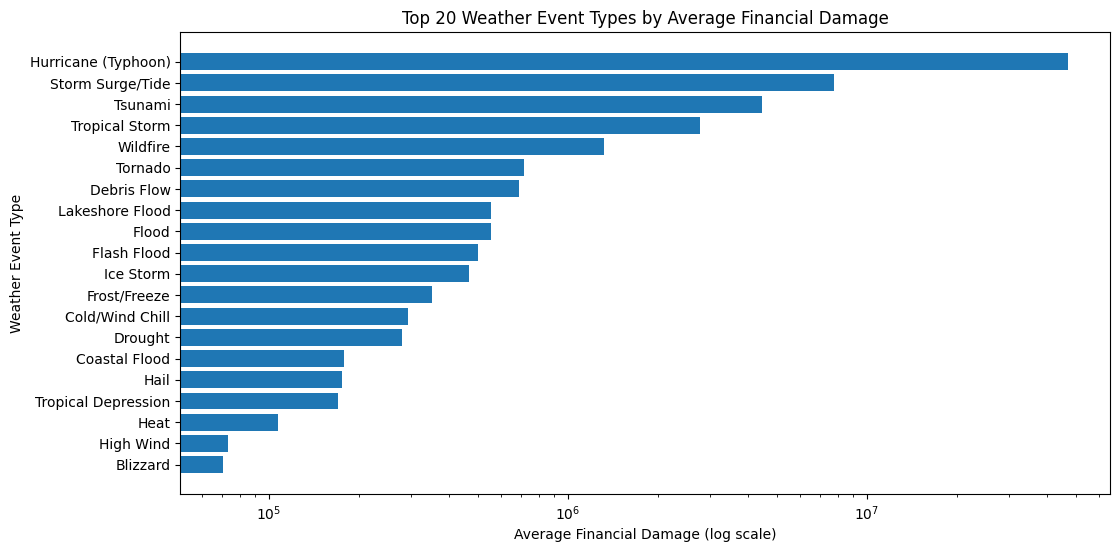

In [24]:
# Average financial damage by weather event type

damage_by_event = (
    df.groupby("event_type")["damage"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

# Plot top 20 weather event types by average financial damage

plt.figure(figsize=(12,6))

plt.barh(damage_by_event.index, damage_by_event.values)

plt.xscale("log")

plt.title("Top 20 Weather Event Types by Average Financial Damage")
plt.xlabel("Average Financial Damage (log scale)")
plt.ylabel("Weather Event Type")

plt.gca().invert_yaxis()

plt.show()

**Interpretation:**

The graph illustrates the average financial losses associated with different types of severe weather events. The results show that **Hurricane (Typhoon)** events cause by far the highest average economic damage compared to all other weather categories.

Other events with high average financial impacts include:

- Storm Surge/Tide  
- Tsunami  
- Tropical Storm  
- Wildfire  
- Tornado  

These types of events are typically associated with large-scale destruction, including damage to infrastructure, homes, transportation systems, agriculture, and coastal areas.

Although some events such as thunderstorms or hail occur more frequently in the dataset, they do not necessarily produce the highest financial losses. This demonstrates that event frequency and economic severity are not directly related.

The logarithmic scale was used to improve the readability of the visualization and to allow better comparisons between event categories with very different damage values.

Overall, the analysis highlights that a relatively small number of extreme weather events are responsible for the largest economic losses in the dataset.

- #### Average Financial Damage by State/Territory

In [25]:
# Number of unique states/territories
print("Total states/territories:", df["state"].nunique())

# Check unique state/territory names
sorted(df["state"].str.upper().unique())

Total states/territories: 70


['ALABAMA',
 'ALASKA',
 'AMERICAN SAMOA',
 'ARIZONA',
 'ARKANSAS',
 'ATLANTIC NORTH',
 'ATLANTIC SOUTH',
 'CALIFORNIA',
 'COLORADO',
 'CONNECTICUT',
 'DELAWARE',
 'DISTRICT OF COLUMBIA',
 'E PACIFIC',
 'FLORIDA',
 'GEORGIA',
 'GUAM',
 'GUAM WATERS',
 'GULF OF ALASKA',
 'GULF OF MEXICO',
 'HAWAII',
 'HAWAII WATERS',
 'IDAHO',
 'ILLINOIS',
 'INDIANA',
 'IOWA',
 'KANSAS',
 'KENTUCKY',
 'LAKE ERIE',
 'LAKE HURON',
 'LAKE MICHIGAN',
 'LAKE ONTARIO',
 'LAKE ST CLAIR',
 'LAKE SUPERIOR',
 'LOUISIANA',
 'MAINE',
 'MARYLAND',
 'MASSACHUSETTS',
 'MICHIGAN',
 'MINNESOTA',
 'MISSISSIPPI',
 'MISSOURI',
 'MONTANA',
 'NEBRASKA',
 'NEVADA',
 'NEW HAMPSHIRE',
 'NEW JERSEY',
 'NEW MEXICO',
 'NEW YORK',
 'NORTH CAROLINA',
 'NORTH DAKOTA',
 'OHIO',
 'OKLAHOMA',
 'OREGON',
 'PENNSYLVANIA',
 'PUERTO RICO',
 'RHODE ISLAND',
 'SOUTH CAROLINA',
 'SOUTH DAKOTA',
 'ST LAWRENCE R',
 'TENNESSEE',
 'TEXAS',
 'UNKNOWN',
 'UTAH',
 'VERMONT',
 'VIRGIN ISLANDS',
 'VIRGINIA',
 'WASHINGTON',
 'WEST VIRGINIA',
 'WISCONSIN'

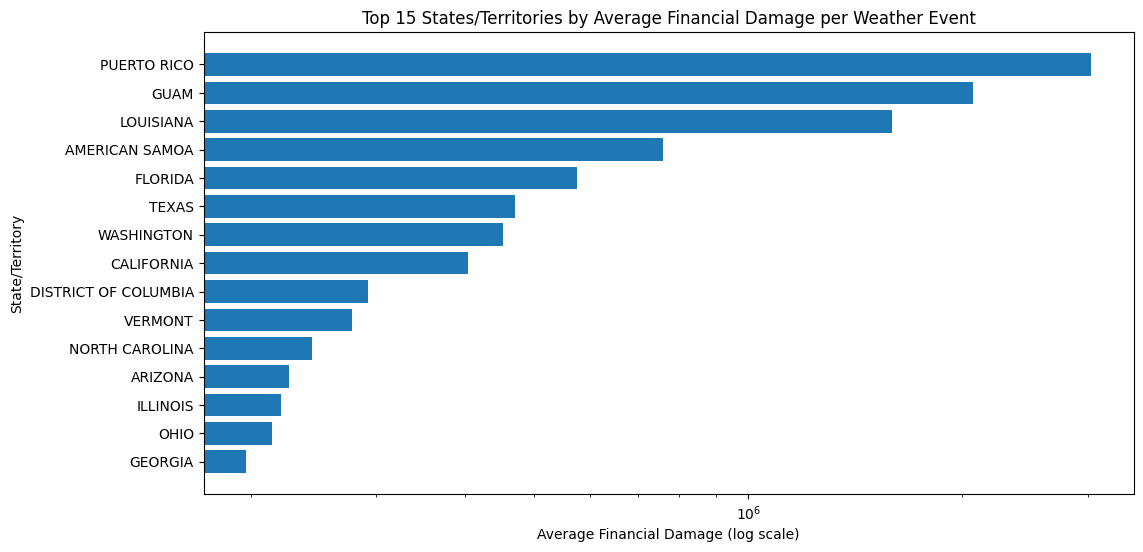

In [26]:
# Average financial damage by state/territory

damage_by_state = (
    df.groupby("state")["damage"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

# Plot average financial damage by state/territory

plt.figure(figsize=(12,6))

plt.barh(damage_by_state.index, damage_by_state.values)

plt.xscale("log")

plt.title("Top 15 States/Territories by Average Financial Damage per Weather Event")
plt.xlabel("Average Financial Damage (log scale)")
plt.ylabel("State/Territory")

plt.gca().invert_yaxis()

plt.show()

**Interpretation:**

The graph shows the average financial loss caused by weather events in different U.S. states and territories.
- Puerto Rico, Guam, and Louisiana record the highest average damages, meaning that a single weather event in these regions tends to produce larger economic losses compared to other areas.
- This is likely related to severe events such as hurricanes, tropical storms, and coastal flooding, which can cause extensive infrastructure and property damage.

Overall, the analysis suggests that coastal and tropical regions are more vulnerable to high-cost weather disasters.

- #### Comparison Between Event Frequency and Financial Damage

In [27]:
# Compare event frequency and average financial damage by state/territory

plt.figure(figsize=(12,8))

# Filled blue bars for number of events
plt.barh(
    comparison.index,
    comparison["events_normalized"],
    color="steelblue",
    label="Number of events"
)

# Transparent red outlined bars for average damage
plt.barh(
    comparison.index,
    comparison["damage_normalized"],
    facecolor="none",
    edgecolor="salmon",
    linewidth=2,
    label="Average financial damage"
)

plt.title("Comparison of Event Frequency and Average Financial Damage by State/Territory")
plt.xlabel("Normalized Value")
plt.ylabel("State/Territory")

plt.legend()

plt.tight_layout()

plt.show()

NameError: name 'comparison' is not defined

<Figure size 1200x800 with 0 Axes>

Interpretation:

The comparison between the number of weather events and the average financial damage shows that:

- Texas records the highest number of severe weather events.
- States with many weather events do not always experience the highest financial losses.
- Puerto Rico and Guam have fewer events overall, but much higher average financial damage per event.
- Louisiana also shows high economic losses compared to its event frequency.
- Some regions are affected by frequent but less severe events, while others experience fewer but much more destructive disasters.

## 3. NLP and Text Analysis

Now that the exploratory data analysis (EDA) is complete, the next step is to analyze the textual weather narratives using Natural Language Processing (NLP).

The goal of this section is to:

preprocess the weather narratives,
extract important words and patterns,
identify commonly used terms in severe weather descriptions,
and explore how language relates to weather damage.

In [28]:
# Combine both narrative columns into one text column

df["full_text"] = df["episode_narrative"] + " " + df["event_narrative"]

# Preview combined text

df.head()

,id,event_type,episode_narrative,event_narrative,damage,begin_date_time,cz_timezone,state,full_text
0,347570,Flash Flood,Tropical Storm Lee formed from a persistent lo...,The Dade County Emergency Management Director ...,10000.0,05-SEP-11 14:30:00,EST-5,GEORGIA,Tropical Storm Lee formed from a persistent lo...
1,1054380,Marine Thunderstorm Wind,Scattered thunderstorms moved across portions ...,A wind gust to 36 knots was measured at the Mo...,0.0,20-SEP-22 17:19:00,CST-6,LAKE MICHIGAN,Scattered thunderstorms moved across portions ...
2,317977,Thunderstorm Wind,"During the evening hours on July 19th, a sever...",Numerous trees and power lines were downed acr...,50000.0,19-JUL-11 22:45:00,EST-5,KENTUCKY,"During the evening hours on July 19th, a sever..."
3,509299,High Wind,An upper-level trough moved through southern C...,The Big Black Mountain mesonet recorded a peak...,0.0,26-APR-14 01:00:00,PST-8,CALIFORNIA,An upper-level trough moved through southern C...
4,1009291,Hail,A small cluster of thunderstorms developed nor...,Quarter size hail fell near Rural.,0.0,12-APR-22 16:16:00,CST-6,WISCONSIN,A small cluster of thunderstorms developed nor...


### 3.1 Text Length Analysis

In [29]:
# Calculate text length

df["text_length"] = df["full_text"].apply(len)

# Summary statistics

df["text_length"].describe()

count    785162.000000
mean        587.239013
std         816.020737
min           2.000000
25%         226.000000
50%         389.000000
75%         685.000000
max       41227.000000
Name: text_length, dtype: float64

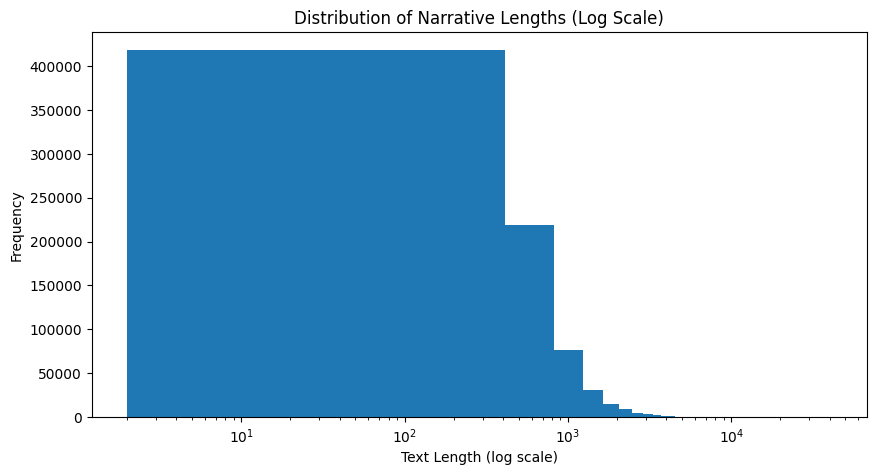

In [30]:
# Plot text length distribution (log scale)

plt.figure(figsize=(10,5))

plt.hist(df["text_length"], bins=100)

plt.xscale("log")

plt.title("Distribution of Narrative Lengths (Log Scale)")
plt.xlabel("Text Length (log scale)")
plt.ylabel("Frequency")

plt.show()

**Interpretation of Narrative Length Distribution**

The graph shows that most weather reports are short and contain only basic information about the event. However, a smaller number of reports are much longer because they describe more serious or complex situations in greater detail.

In practice, this means that severe weather events such as hurricanes, floods, or large storms usually require longer explanations from meteorologists, while smaller events can be described in only a few sentences.

The logarithmic scale helps display both short and very long reports more clearly on the same graph.

In [31]:
import seaborn as sns

I wanted to see if the length of description is the same for all event types, or if certain events need longer descriptions a priori.

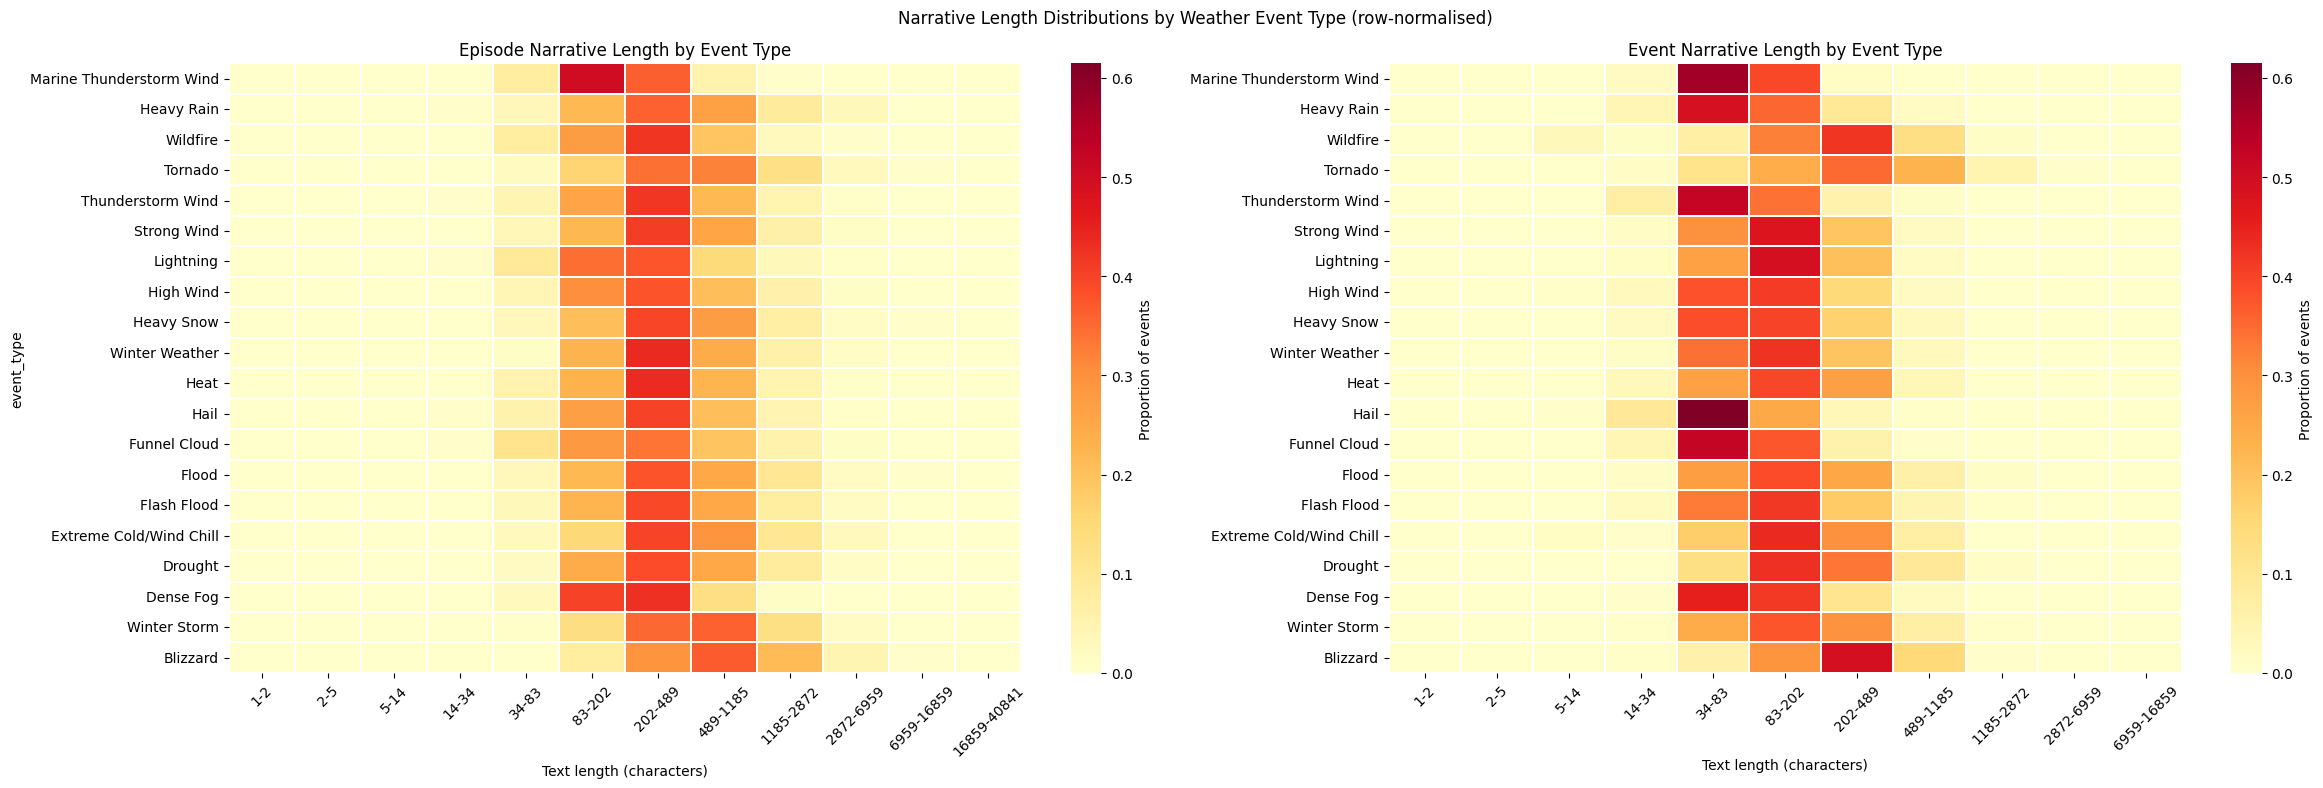

In [32]:
# Compute separate lengths
df["episode_length"] = df["episode_narrative"].apply(len)
df["event_length"]   = df["event_narrative"].apply(len)

# Shared log-spaced bins (computed from both together so axes are comparable)
all_lengths = pd.concat([df["episode_length"], df["event_length"]])
log_bins = np.logspace(np.log10(all_lengths.clip(lower=1).min()),
                       np.log10(all_lengths.max()), 13)
bin_labels = [f"{int(log_bins[i])}-{int(log_bins[i+1])}" for i in range(len(log_bins)-1)]

# Restrict to top 20 event types
top_events = df["event_type"].value_counts().head(20).index
df_top = df[df["event_type"].isin(top_events)].copy()
df_top["ep_bin"] = pd.cut(df_top["episode_length"], bins=log_bins, labels=bin_labels, include_lowest=True)
df_top["ev_bin"] = pd.cut(df_top["event_length"],   bins=log_bins, labels=bin_labels, include_lowest=True)

def make_pivot(data, bin_col):
    p = data.groupby(["event_type", bin_col], observed=True).size().unstack(fill_value=0)
    return p.div(p.sum(axis=1), axis=0)

pivot_ep = make_pivot(df_top, "ep_bin")
pivot_ev = make_pivot(df_top, "ev_bin")

# Sort rows by episode median bin (same order on both plots)
order = pivot_ep.idxmax(axis=1).sort_values().index
pivot_ep, pivot_ev = pivot_ep.loc[order], pivot_ev.loc[order]

vmax = max(pivot_ep.values.max(), pivot_ev.values.max())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 8))
for ax, pivot, title in [
    (ax1, pivot_ep, "Episode Narrative"),
    (ax2, pivot_ev, "Event Narrative"),
]:
    sns.heatmap(pivot, cmap="YlOrRd", ax=ax, linewidths=0.3,
                vmin=0, vmax=vmax, cbar_kws={"label": "Proportion of events"})
    ax.set_title(f"{title} Length by Event Type")
    ax.set_xlabel("Text length (characters)")
    ax.tick_params(axis="x", rotation=45)

ax2.set_ylabel("")
plt.suptitle("Narrative Length Distributions by Weather Event Type (row-normalised)")
plt.tight_layout()
plt.show()

There is no noticeable difference in the length of `episode_narrative` for different `event_types`.
`event_narrative` has, on average, fewer characters than `episode_narrative`: notice that the heatmap is essentially skewed one or two bins to the left. However, we can see that some event types are described with a smaller number of characters, such as "hail", "marine thunderstorm wind" and "thunderstorm wind". Perhaps because these are more common and thus language has evolved in needing fewer words to describe them and/or their impact.

I also wanted to answer the question of whether `damage` had any correlation with `episode_narrative` or `event_narrative` length.

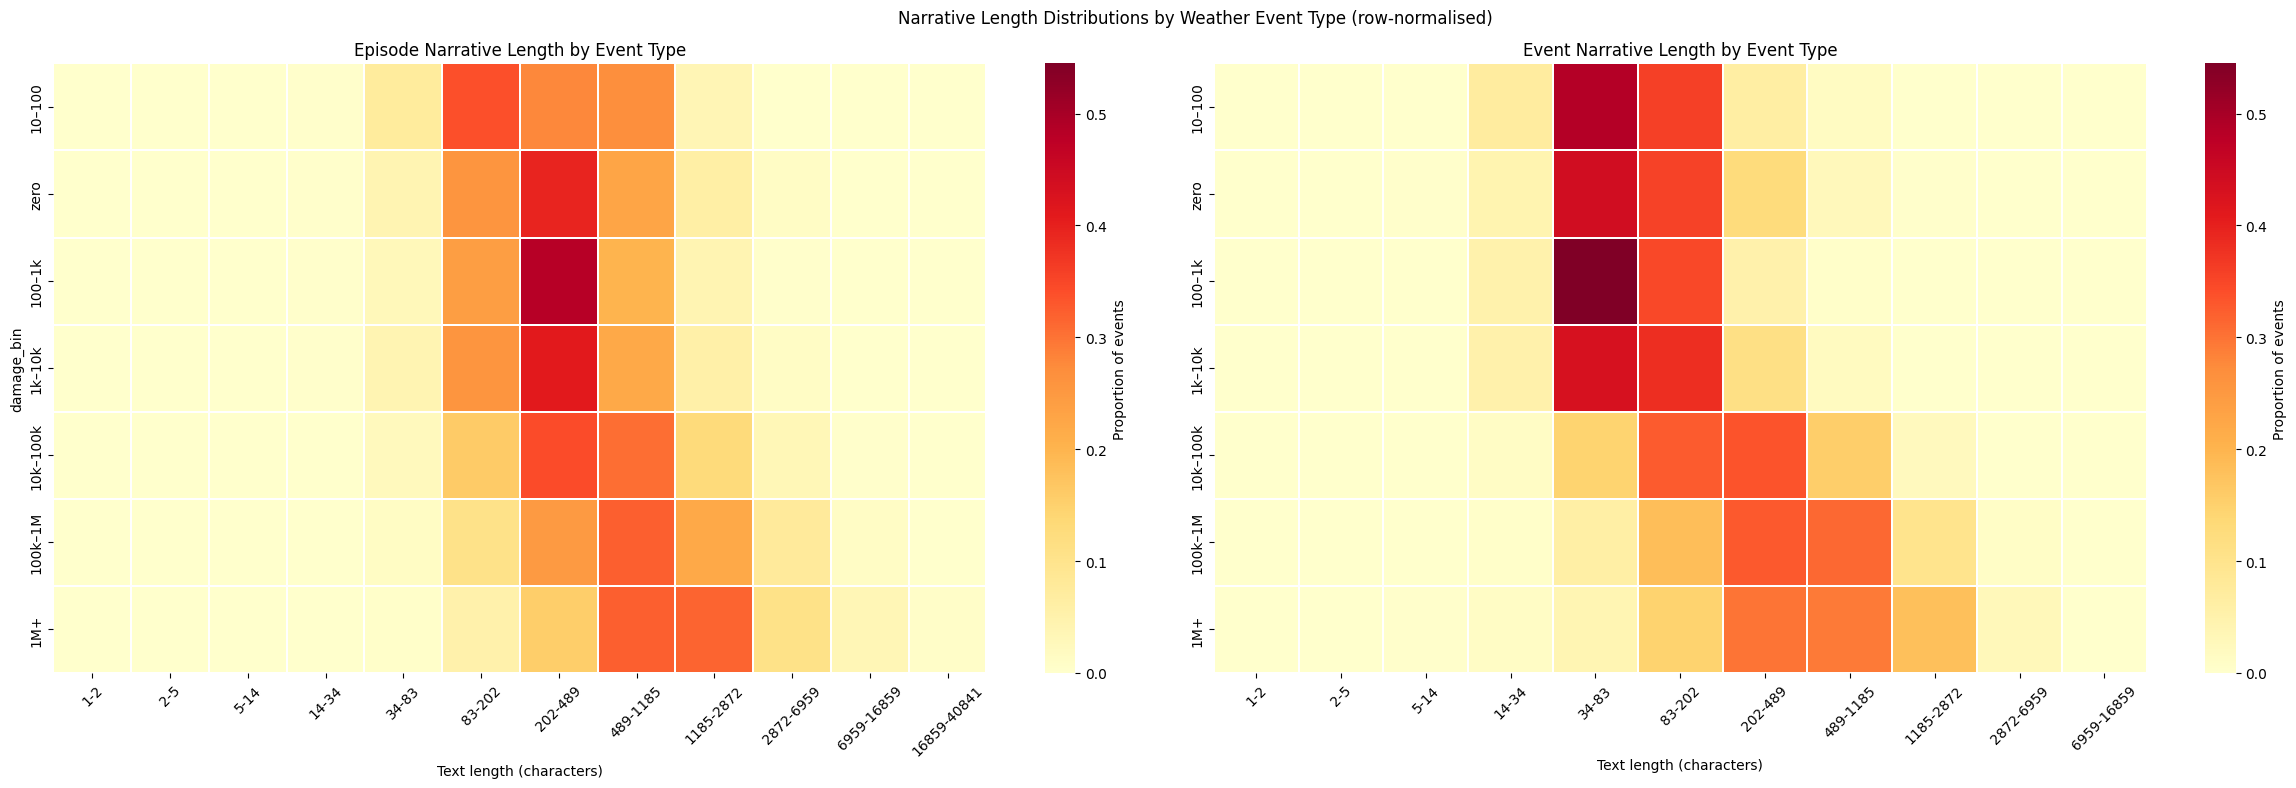

In [33]:
# Compute separate lengths
df["episode_length"] = df["episode_narrative"].apply(len)
df["event_length"]   = df["event_narrative"].apply(len)

# Shared log-spaced bins (computed from both together so axes are comparable)
all_lengths = pd.concat([df["episode_length"], df["event_length"]])
log_bins = np.logspace(np.log10(all_lengths.clip(lower=1).min()),
                       np.log10(all_lengths.max()), 13)
bin_labels = [f"{int(log_bins[i])}-{int(log_bins[i+1])}" for i in range(len(log_bins)-1)]

# Log-spaced damage bins; zero gets its own label since log(0) is undefined
df_top = df.copy()
log_edges = np.concatenate([[-1, 0], np.logspace(0, np.log10(1 + df["damage"].max()), 7)])
damage_labels = ["zero", "1–10", "10–100", "100–1k", "1k–10k", "10k–100k", "100k–1M", "1M+"]

df_top["damage_bin"] = pd.cut(df_top["damage"], bins=log_edges,
                               labels=damage_labels, include_lowest=True)
df_top["ep_bin"] = pd.cut(df_top["episode_length"], bins=log_bins, labels=bin_labels, include_lowest=True)
df_top["ev_bin"] = pd.cut(df_top["event_length"],   bins=log_bins, labels=bin_labels, include_lowest=True)

def make_pivot(data, bin_col):
    p = data.groupby(["damage_bin", bin_col], observed=True).size().unstack(fill_value=0)
    return p.div(p.sum(axis=1), axis=0)

pivot_ep = make_pivot(df_top, "ep_bin")
pivot_ev = make_pivot(df_top, "ev_bin")

# Sort rows by episode median bin (same order on both plots)
order = pivot_ep.idxmax(axis=1).sort_values().index
pivot_ep, pivot_ev = pivot_ep.loc[order], pivot_ev.loc[order]

vmax = max(pivot_ep.values.max(), pivot_ev.values.max())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 8))
for ax, pivot, title in [
    (ax1, pivot_ep, "Episode Narrative"),
    (ax2, pivot_ev, "Event Narrative"),
]:
    sns.heatmap(pivot, cmap="YlOrRd", ax=ax, linewidths=0.3,
                vmin=0, vmax=vmax, cbar_kws={"label": "Proportion of events"})
    ax.set_title(f"{title} Length by Event Type")
    ax.set_xlabel("Text length (characters)")
    ax.tick_params(axis="x", rotation=45)

ax2.set_ylabel("")
plt.suptitle("Narrative Length Distributions by Weather Event Type (row-normalised)")
plt.tight_layout()
plt.show()

Unsurprisingly, text length increases with increasing damages. Since we have seen before that certain weather events produce more damage on average (e.g. tsunamis, tropical storms, wildfires), predictions of our model with respect to these might be better than with respect to those that cause less damage due to the greater abundance of text describing the most damaging ones.

### 3.2 Text Cleaning and Normalization

In [34]:
#Example of what we are doing in the next cell#

import string
import nltk
wnl = nltk.stem.WordNetLemmatizer()

string.punctuation
_punct_table = str.maketrans("", "", string.punctuation)
stopwords = nltk.corpus.stopwords.words("english")

episode_exmpl = df["episode_narrative"].iloc[45920]
event_exmpl = df["event_narrative"].iloc[45920]

episode_exmpl_tokens = nltk.word_tokenize(episode_exmpl)
event_exmpl_tokens = nltk.word_tokenize(event_exmpl)

episode_PoS_u = nltk.pos_tag(episode_exmpl_tokens, tagset="universal")
event_PoS_u = nltk.pos_tag(event_exmpl_tokens, tagset='universal')

# ================== #

def custom_tokenizer(text: str):
    text = text.lower().translate(_punct_table)
    text_tokens = nltk.word_tokenize(text)
    output = []
    for w, pos in nltk.pos_tag(text_tokens, tagset="universal"):
        if pos in ["VERB"]:
            pos = "v"
        elif pos in ["ADJ"]:
            pos = "a"
        elif pos in ["ADV"]:
            pos = "r"
        elif pos in ["NOUN"]:
            pos = "n"
        else:
            pos = "n"

        # Lemmatized form accounting for POS-tag
        l = wnl.lemmatize(w, pos=pos)

        # Filter out stopwords
        if l not in stopwords:
            output.append(l)

    return output

print(episode_exmpl)
print(episode_exmpl_tokens)
print(episode_PoS_u)
print(custom_tokenizer(episode_exmpl))

print(event_exmpl)
print(event_exmpl_tokens)
print(event_PoS_u)
print(custom_tokenizer(event_exmpl))

Numerous thunderstorms were triggered by an upper level disturbance moving through a warm, moist and unstable air mass over New York. Localized areas of flash flooding were reported across the central Leatherstocking region of upstate NY.
['Numerous', 'thunderstorms', 'were', 'triggered', 'by', 'an', 'upper', 'level', 'disturbance', 'moving', 'through', 'a', 'warm', ',', 'moist', 'and', 'unstable', 'air', 'mass', 'over', 'New', 'York', '.', 'Localized', 'areas', 'of', 'flash', 'flooding', 'were', 'reported', 'across', 'the', 'central', 'Leatherstocking', 'region', 'of', 'upstate', 'NY', '.']
[('Numerous', 'ADJ'), ('thunderstorms', 'NOUN'), ('were', 'VERB'), ('triggered', 'VERB'), ('by', 'ADP'), ('an', 'DET'), ('upper', 'ADJ'), ('level', 'NOUN'), ('disturbance', 'NOUN'), ('moving', 'VERB'), ('through', 'ADP'), ('a', 'DET'), ('warm', 'ADJ'), (',', '.'), ('moist', 'ADJ'), ('and', 'CONJ'), ('unstable', 'ADJ'), ('air', 'NOUN'), ('mass', 'NOUN'), ('over', 'ADP'), ('New', 'NOUN'), ('York', 'N

We realized there were a number of text entries with Unicode replacement characters that crept thru the cleaning and normalization procedures in the following cell, so we added a step to further clean non-ASCII characters before tokenization.

In [ ]:
df["full_text"] = df["full_text"].str.encode("ascii", errors="ignore").str.decode("ascii")

Tokenizer, Part-of-Speech-tagger, lemmatizer utility function.

In [35]:
import string
import nltk

wnl = nltk.stem.WordNetLemmatizer()
_punct_table = str.maketrans("", "", string.punctuation)
stopwords = nltk.corpus.stopwords.words("english")

def custom_tokenizer_lemmatizer(text: str) -> list:
    text = text.lower().translate(_punct_table) # Removing upper casing and punctuation
    text_tokens = nltk.word_tokenize(text) # Tokenizing text after removing punctuation and upper casing
    output = []
    for w, pos in nltk.pos_tag(text_tokens, tagset="universal"): # Mapping the set of Part-of-Speech tags for the lemmatizer
        if pos in ["VERB"]:
            pos = "v"
        elif pos in ["ADJ"]:
            pos = "a"
        elif pos in ["ADV"]:
            pos = "r"
        elif pos in ["NOUN"]:
            pos = "n"
        else:
            pos = "n"

        l = wnl.lemmatize(w, pos=pos)

        if l not in stopwords: # Filtering out stopwords
            output.append(l)

    return output

In [36]:
df["episode_tokens"] = df["episode_narrative"].apply(custom_tokenizer_lemmatizer)
df["episode_clean"] = df["episode_tokens"].apply(" ".join)

df["event_tokens"] = df["event_narrative"].apply(custom_tokenizer_lemmatizer)
df["event_clean"] = df["event_tokens"].apply(" ".join)

df["full_tokens"] = df["full_text"].apply(custom_tokenizer_lemmatizer)
df["clean_text"] = df["full_tokens"].apply(" ".join)

In [37]:
df[["episode_narrative", "episode_clean", "episode_tokens", "event_narrative", "event_clean", "event_tokens", "full_text", "clean_text", "full_tokens"]].head()

,episode_narrative,episode_clean,episode_tokens,event_narrative,event_clean,event_tokens,full_text,clean_text,full_tokens
0,Tropical Storm Lee formed from a persistent lo...,tropical storm lee form persistent low pressur...,"[tropical, storm, lee, form, persistent, low, ...",The Dade County Emergency Management Director ...,dade county emergency management director repo...,"[dade, county, emergency, management, director...",Tropical Storm Lee formed from a persistent lo...,tropical storm lee form persistent low pressur...,"[tropical, storm, lee, form, persistent, low, ..."
1,Scattered thunderstorms moved across portions ...,scattered thunderstorm move across portion sou...,"[scattered, thunderstorm, move, across, portio...",A wind gust to 36 knots was measured at the Mo...,wind gust 36 knot measure montrose harbor light,"[wind, gust, 36, knot, measure, montrose, harb...",Scattered thunderstorms moved across portions ...,scattered thunderstorm move across portion sou...,"[scattered, thunderstorm, move, across, portio..."
2,"During the evening hours on July 19th, a sever...",evening hour july 19th severe thunderstorm bri...,"[evening, hour, july, 19th, severe, thundersto...",Numerous trees and power lines were downed acr...,numerous tree power line across western portio...,"[numerous, tree, power, line, across, western,...","During the evening hours on July 19th, a sever...",evening hour july 19th severe thunderstorm bri...,"[evening, hour, july, 19th, severe, thundersto..."
3,An upper-level trough moved through southern C...,upperlevel trough move southern california str...,"[upperlevel, trough, move, southern, californi...",The Big Black Mountain mesonet recorded a peak...,big black mountain mesonet record peak wind gu...,"[big, black, mountain, mesonet, record, peak, ...",An upper-level trough moved through southern C...,upperlevel trough move southern california str...,"[upperlevel, trough, move, southern, californi..."
4,A small cluster of thunderstorms developed nor...,small cluster thunderstorm develop north warm ...,"[small, cluster, thunderstorm, develop, north,...",Quarter size hail fell near Rural.,quarter size hail fell near rural,"[quarter, size, hail, fell, near, rural]",A small cluster of thunderstorms developed nor...,small cluster thunderstorm develop north warm ...,"[small, cluster, thunderstorm, develop, north,..."


Creating a damage tier classification for potential future analyses

In [38]:
# Damage tier classification: zero + 5 quintiles of log1p(damage) for non-zero events

TIER_LABELS = {0: "zero", 1: "very low", 2: "low", 3: "medium", 4: "high", 5: "extreme"}

df["damage_tier"] = 0  # default: zero tier

nonzero_mask = df["damage"] > 0
bins = [0, 1_000, 10_000, 100_000, 1_000_000, float("inf")]

df.loc[nonzero_mask, "damage_tier"] = pd.cut(
    df.loc[nonzero_mask, "damage"],
    bins=bins,
    labels=[1, 2, 3, 4, 5],
    right=False,
    include_lowest=True
).astype(int)

df["damage_tier_label"] = df["damage_tier"].map(TIER_LABELS)

df["damage_tier_label"].value_counts().sort_index()

damage_tier_label
extreme       8876
high         23759
low         105072
medium       80538
very low     13829
zero        553088
Name: count, dtype: int64

In [39]:
df.head()

,id,event_type,episode_narrative,event_narrative,damage,begin_date_time,cz_timezone,state,full_text,text_length,episode_length,event_length,episode_tokens,episode_clean,event_tokens,event_clean,full_tokens,clean_text,damage_tier,damage_tier_label
0,347570,Flash Flood,Tropical Storm Lee formed from a persistent lo...,The Dade County Emergency Management Director ...,10000.0,05-SEP-11 14:30:00,EST-5,GEORGIA,Tropical Storm Lee formed from a persistent lo...,2761,2311,449,"[tropical, storm, lee, form, persistent, low, ...",tropical storm lee form persistent low pressur...,"[dade, county, emergency, management, director...",dade county emergency management director repo...,"[tropical, storm, lee, form, persistent, low, ...",tropical storm lee form persistent low pressur...,3,medium
1,1054380,Marine Thunderstorm Wind,Scattered thunderstorms moved across portions ...,A wind gust to 36 knots was measured at the Mo...,0.0,20-SEP-22 17:19:00,CST-6,LAKE MICHIGAN,Scattered thunderstorms moved across portions ...,157,90,66,"[scattered, thunderstorm, move, across, portio...",scattered thunderstorm move across portion sou...,"[wind, gust, 36, knot, measure, montrose, harb...",wind gust 36 knot measure montrose harbor light,"[scattered, thunderstorm, move, across, portio...",scattered thunderstorm move across portion sou...,0,zero
2,317977,Thunderstorm Wind,"During the evening hours on July 19th, a sever...",Numerous trees and power lines were downed acr...,50000.0,19-JUL-11 22:45:00,EST-5,KENTUCKY,"During the evening hours on July 19th, a sever...",445,294,150,"[evening, hour, july, 19th, severe, thundersto...",evening hour july 19th severe thunderstorm bri...,"[numerous, tree, power, line, across, western,...",numerous tree power line across western portio...,"[evening, hour, july, 19th, severe, thundersto...",evening hour july 19th severe thunderstorm bri...,3,medium
3,509299,High Wind,An upper-level trough moved through southern C...,The Big Black Mountain mesonet recorded a peak...,0.0,26-APR-14 01:00:00,PST-8,CALIFORNIA,An upper-level trough moved through southern C...,589,306,282,"[upperlevel, trough, move, southern, californi...",upperlevel trough move southern california str...,"[big, black, mountain, mesonet, record, peak, ...",big black mountain mesonet record peak wind gu...,"[upperlevel, trough, move, southern, californi...",upperlevel trough move southern california str...,0,zero
4,1009291,Hail,A small cluster of thunderstorms developed nor...,Quarter size hail fell near Rural.,0.0,12-APR-22 16:16:00,CST-6,WISCONSIN,A small cluster of thunderstorms developed nor...,335,300,34,"[small, cluster, thunderstorm, develop, north,...",small cluster thunderstorm develop north warm ...,"[quarter, size, hail, fell, near, rural]",quarter size hail fell near rural,"[small, cluster, thunderstorm, develop, north,...",small cluster thunderstorm develop north warm ...,0,zero


### 3.3 Bigram frequency

Computing what are the most common bigrams in each damage tier.

In [40]:
from nltk.lm import MLE
from nltk.lm.preprocessing import padded_everygram_pipeline
from collections import Counter
import random

_PADDING = {"<s>", "</s>"}

def fit_mle_and_top_ngrams(token_lists, order=2, top_k=15, max_samples=20_000, seed=42):
    # Avoiding going thru every single document because zero damage, for example, would be ~500k documents - too long #
    if len(token_lists) > max_samples:
        rng = random.Random(seed)
        token_lists = rng.sample(token_lists, max_samples)

    train_data, vocab = padded_everygram_pipeline(order=order, text=token_lists)
    model = MLE(order=order)
    model.fit(train_data, vocab)

    # Obtaining the count #
    counter = Counter()
    cfd = model.counts._counts[order]
    for context in cfd.conditions():
        if any(t in _PADDING for t in context):
            continue
        for word, count in cfd[context].items():
            if word not in _PADDING:
                counter[context + (word,)] = count

    return model, counter.most_common(top_k)

def top_ngrams_by_damage_tier(df, token_col, order=2, top_k=15, max_samples=20_000):
    # Fitting one model for each damage tier #
    models, results = {}, {}
    for tier in sorted(df["damage_tier"].unique()):
        token_lists = df[df["damage_tier"] == tier][token_col].tolist()
        models[tier], results[tier] = fit_mle_and_top_ngrams(
            token_lists, order=order, top_k=top_k, max_samples=max_samples
        )
    return models, results

ep_bi_models_damage,  ep_bigrams_damage  = top_ngrams_by_damage_tier(df, "episode_tokens", order=2)
ep_tri_models_damage, ep_trigrams_damage = top_ngrams_by_damage_tier(df, "episode_tokens", order=3)
ev_bi_models_damage,  ev_bigrams_damage  = top_ngrams_by_damage_tier(df, "event_tokens",   order=2)
ev_tri_models_damage, ev_trigrams_damage = top_ngrams_by_damage_tier(df, "event_tokens",   order=3)

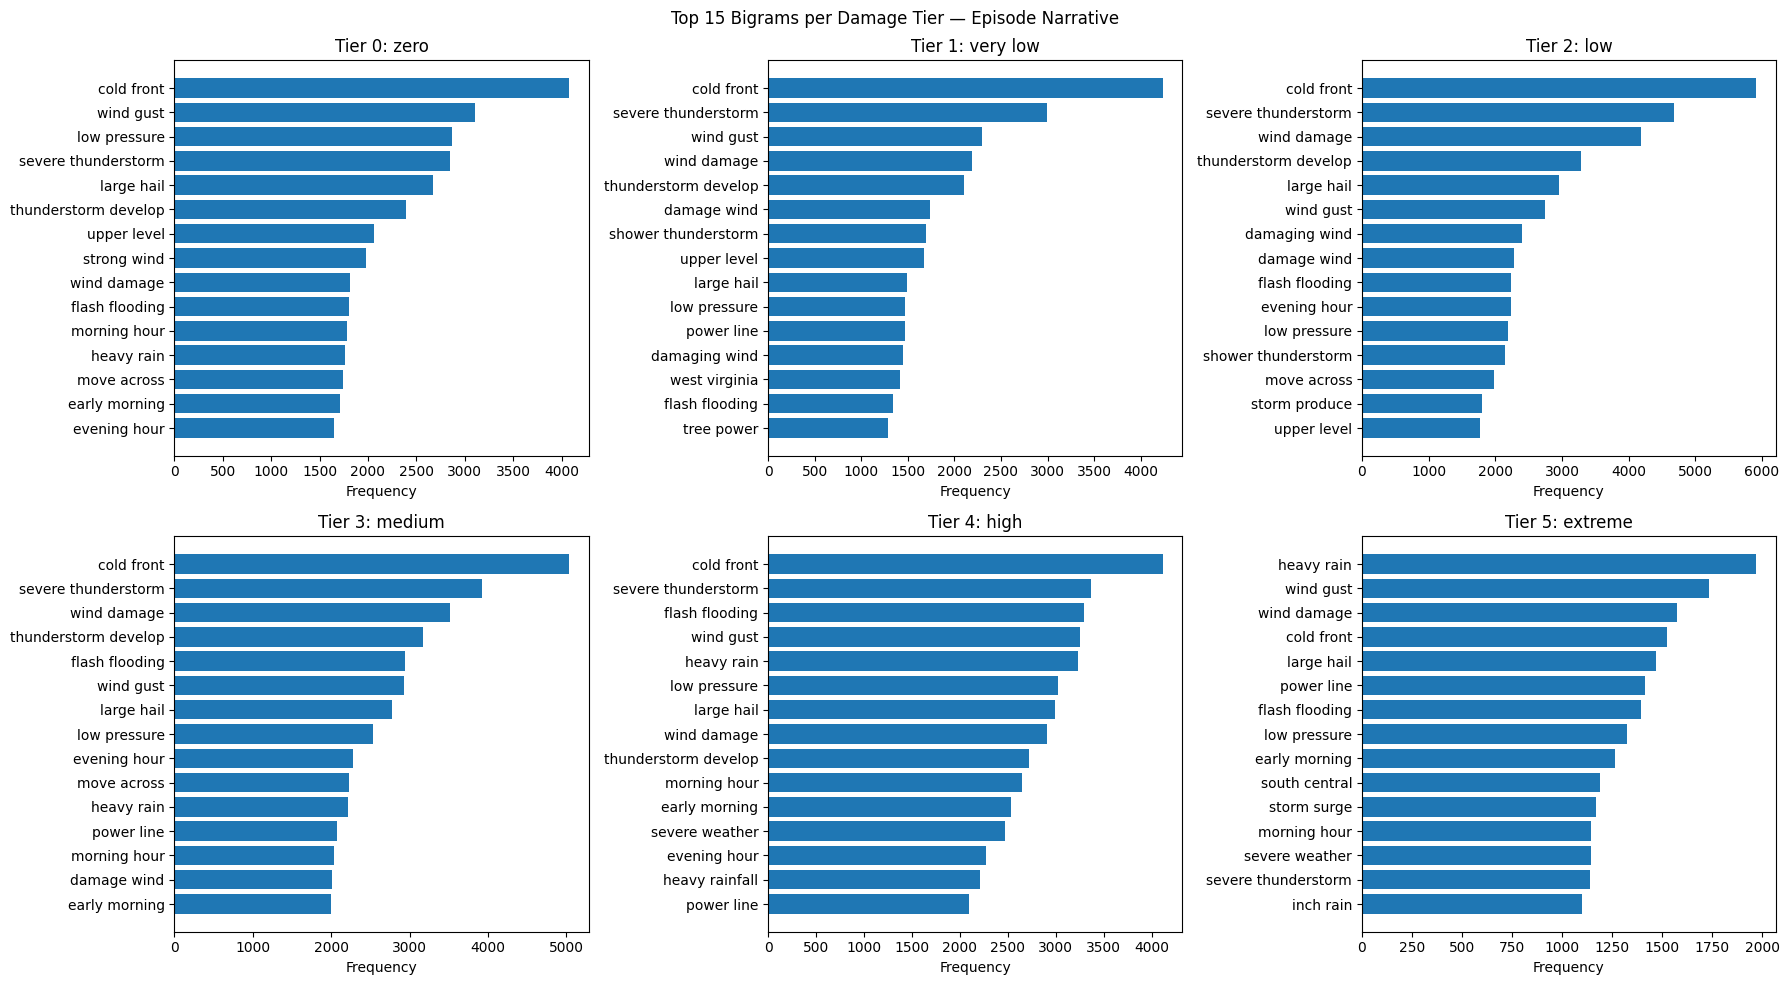

In [41]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (tier, label) in enumerate(TIER_LABELS.items()):
    words  = [" ".join(bg) for bg, _ in ep_bigrams_damage[tier]]
    counts = [cnt for _, cnt in ep_bigrams_damage[tier]]
    axes[i].barh(words[::-1], counts[::-1])
    axes[i].set_title(f"Tier {tier}: {label}")
    axes[i].set_xlabel("Frequency")

plt.suptitle("Top 15 Bigrams per Damage Tier — Episode Narrative")
plt.tight_layout()
plt.show()

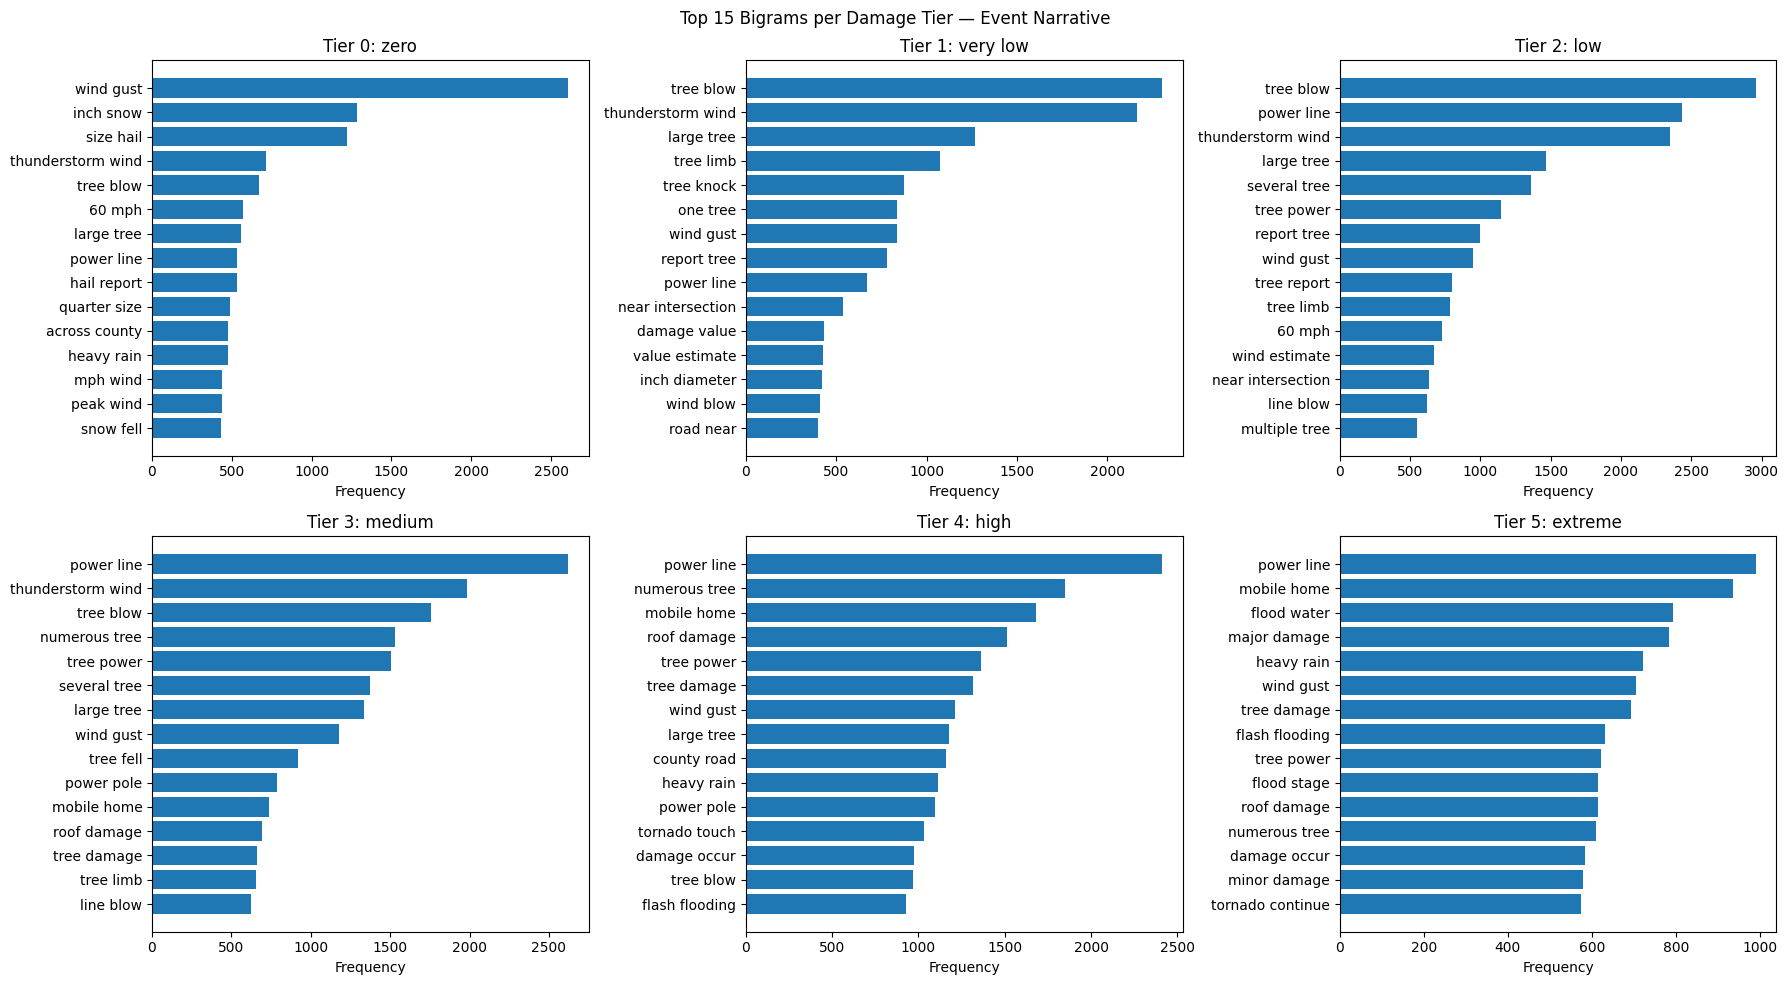

In [42]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (tier, label) in enumerate(TIER_LABELS.items()):
    words  = [" ".join(bg) for bg, _ in ev_bigrams_damage[tier]]
    counts = [cnt for _, cnt in ev_bigrams_damage[tier]]
    axes[i].barh(words[::-1], counts[::-1])
    axes[i].set_title(f"Tier {tier}: {label}")
    axes[i].set_xlabel("Frequency")

plt.suptitle("Top 15 Bigrams per Damage Tier — Event Narrative")
plt.tight_layout()
plt.show()

The analysis ends up not being great at finding bigrams that are much more important in more damaging events.
We can see, from `episode_narrative`, that "Heavy rain" increasingly dominates bigram frequency with increasing damage tier. From `event_narrative`, we see the same happening to "Power line" and "Mobile home" - events with greater damage impact people directly, and it becomes more important to speak of damage rather than the meteorological features.

Doing the same analysis for the event type - only the 15 most common.

In [43]:
def top_ngrams_by_event_type(df, token_col, order=2, top_k=15, max_samples=20_000):
    """Fit one MLE model per damage tier; return models and top n-grams."""
    models, results = {}, {}
    for tier in sorted(df["event_type"].unique()):
        token_lists = df[df["event_type"] == tier][token_col].tolist()
        models[tier], results[tier] = fit_mle_and_top_ngrams(
            token_lists, order=order, top_k=top_k, max_samples=max_samples
        )
    return models, results

# Restricting to top 15 events #
top_15_events = df["event_type"].value_counts().head(15).index
df_top15 = df[df["event_type"].isin(top_15_events)]

ep_bi_models_event_typ,  ep_bigrams_event_typ  = top_ngrams_by_event_type(df_top15, "episode_tokens", order=2)
ep_tri_models_event_typ, ep_trigrams_event_typ = top_ngrams_by_event_type(df_top15, "episode_tokens", order=3)
ev_bi_models_event_typ,  ev_bigrams_event_typ  = top_ngrams_by_event_type(df_top15, "event_tokens",   order=2)
ev_tri_models_event_typ, ev_trigrams_event_typ = top_ngrams_by_event_type(df_top15, "event_tokens",   order=3)

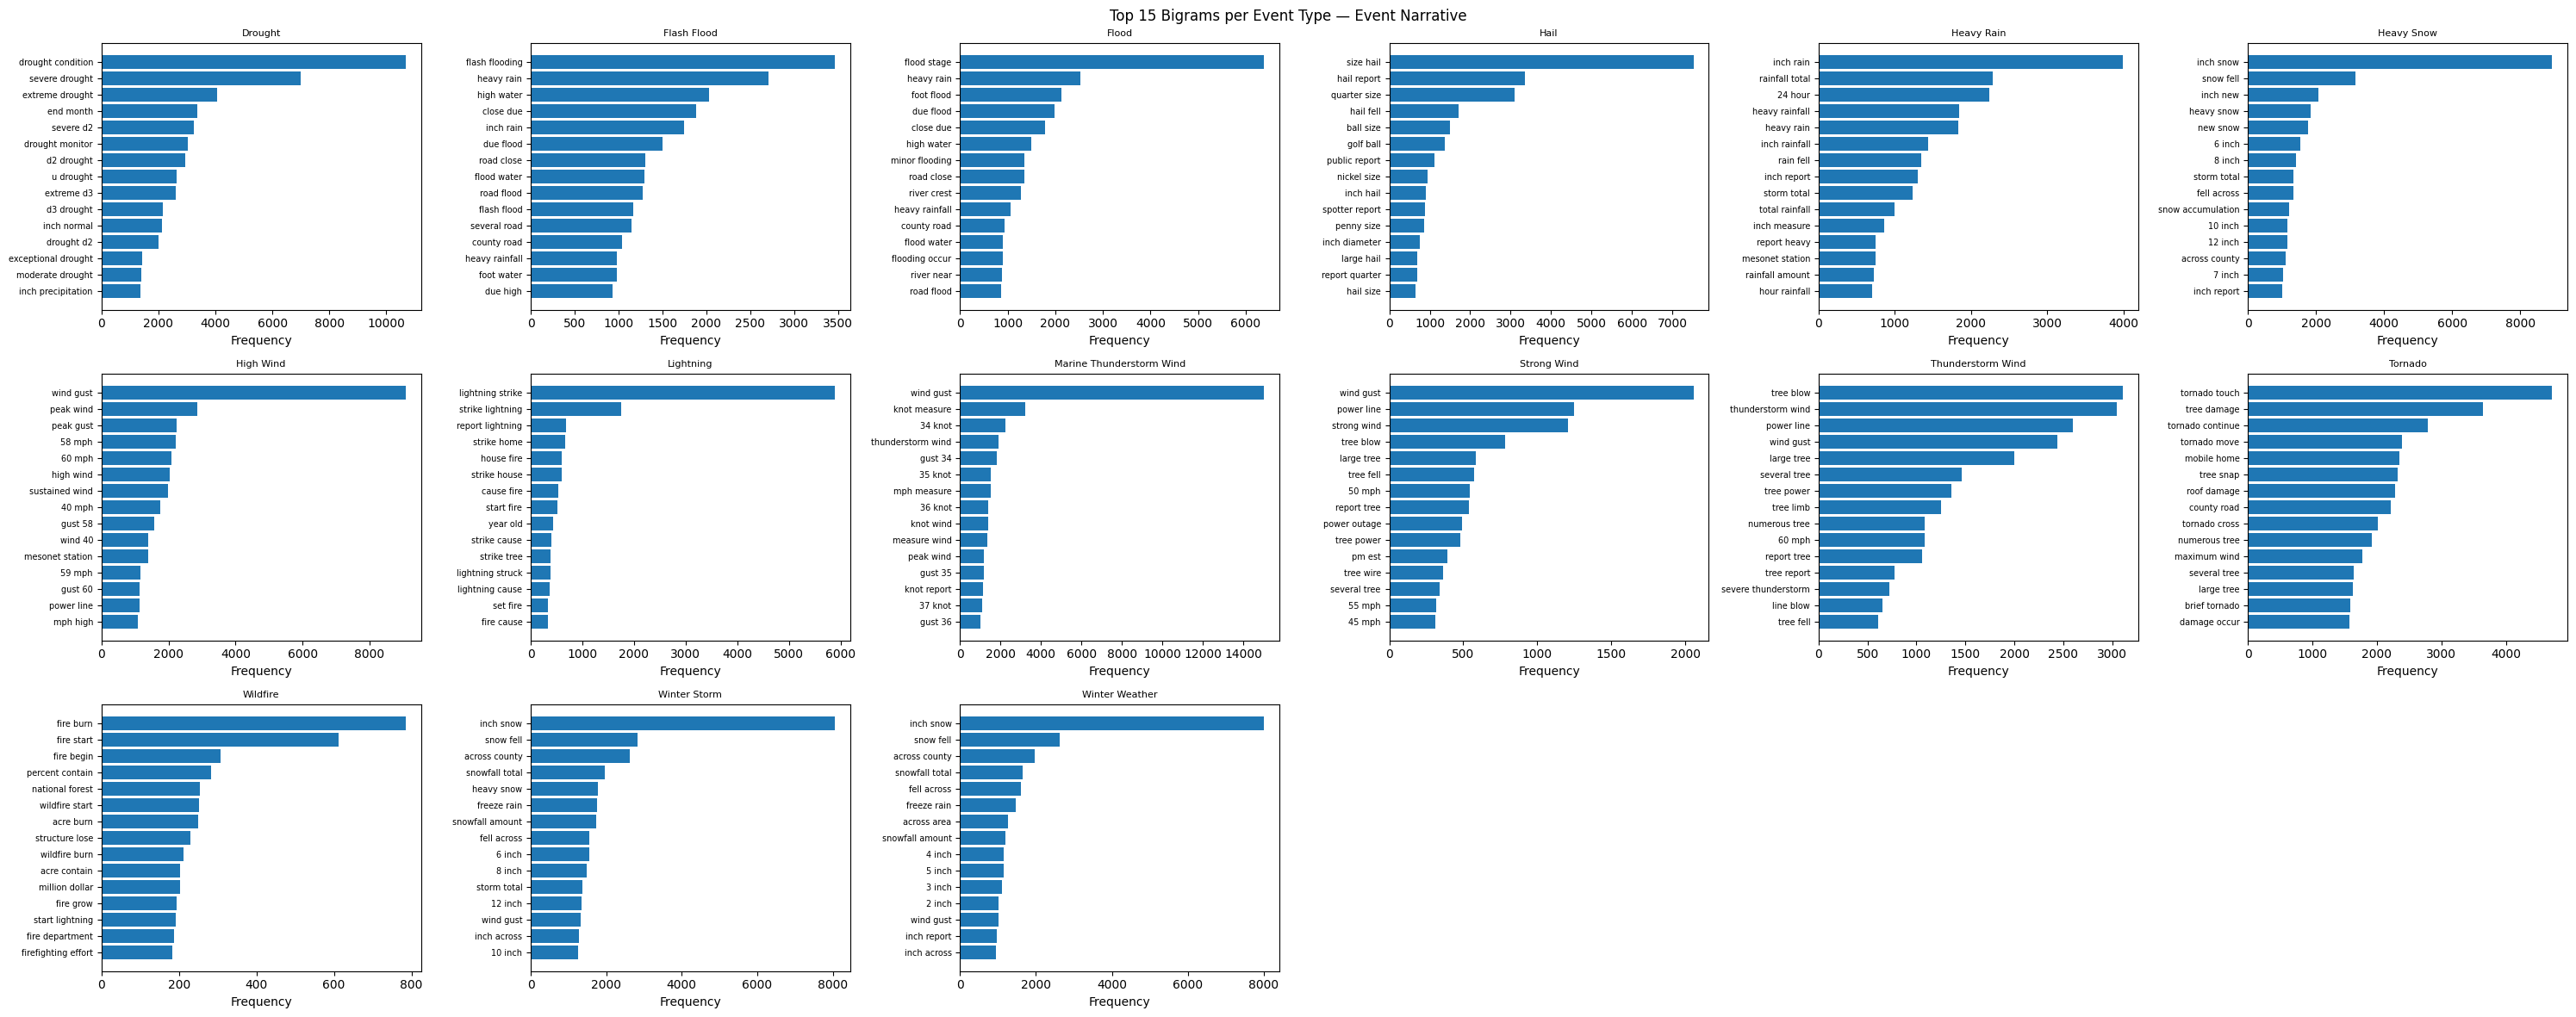

In [44]:
n = len(ev_bigrams_event_typ)
ncols = 6
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
axes = axes.flatten()

for i, (event_type, ngrams) in enumerate(ev_bigrams_event_typ.items()):
    words  = [" ".join(bg) for bg, _ in ngrams]
    counts = [cnt for _, cnt in ngrams]
    axes[i].barh(words[::-1], counts[::-1])
    axes[i].set_title(event_type, fontsize=8)
    axes[i].set_xlabel("Frequency")
    axes[i].tick_params(axis="y", labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Top 15 Bigrams per Event Type — Event Narrative")
plt.tight_layout()
plt.show()

### 3.4 Perplexity score

Now we are going to perform perplexity analysis on the text.

Since perplexity is a measure of how surprised a model is by text it has not seen, we train (like we did before with MLE) a Laplace model - to avoid the problem of zero counts - on a given damage tier and then compute the perplexity on the remaining damage tiers. This will tell us if text differs between damage tiers, i.e. if perplexity scores are high off diagonal, then the damage tier the model was trained on uses language that is not found as much in the damage tier it is being tested on.

The previous analysis was not the best in showing how text differs between damage tiers. It's important for us to know whether there is a difference in language depending on the damage tier in order to answer our question: ***are agressive and damaging weather events becoming more common through the years?***

In [45]:
from nltk.lm import Laplace
from nltk.lm.preprocessing import pad_both_ends
from nltk.util import ngrams as nltk_ngrams
import numpy as np

# Using Laplace instead of MLE in order to correct bigrams that appear 0 times #
# Once again capping documents to 20k, but some tiers have less than 20k documents #
# MAYBE WE NEED TO CHANGE THE TIERING SYSTEM TO ONE THAT ENSURES EQUAL NUMBER OF SAMPLES - EQUAL QUANTILE #
def fit_laplace(token_lists, order=2, max_samples=20_000, seed=42):
    if len(token_lists) > max_samples:
        token_lists = random.Random(seed).sample(token_lists, max_samples)
    train_data, vocab = padded_everygram_pipeline(order=order, text=token_lists)
    model = Laplace(order=order)
    model.fit(train_data, vocab)
    return model

# Defining the perplexity computation #
def compute_perplexity(model, token_lists, order, max_samples=5_000, seed=42):
    if len(token_lists) > max_samples:
        token_lists = random.Random(seed).sample(token_lists, max_samples)
    test_ngrams = []
    for tokens in token_lists:
        test_ngrams += list(nltk_ngrams(pad_both_ends(tokens, n=order), n=order))
    return model.perplexity(test_ngrams)

ORDER = 2
tiers = sorted(df["damage_tier"].unique())
tier_names = [TIER_LABELS[t] for t in tiers]

def cross_perplexity_matrix(df, token_col, order=ORDER):
    # Fit one Laplace model per tier
    models = {
        tier: fit_laplace(df[df["damage_tier"] == tier][token_col].tolist(), order=order)
        for tier in tiers
    }
    # Evaluate every model on every tier's test corpus
    matrix = np.zeros((len(tiers), len(tiers)))
    for i, train_tier in enumerate(tiers):
        for j, test_tier in enumerate(tiers):
            test_lists = df[df["damage_tier"] == test_tier][token_col].tolist()
            matrix[i, j] = compute_perplexity(models[train_tier], test_lists, order)
    return matrix

ep_perp = cross_perplexity_matrix(df, "episode_tokens")
ev_perp = cross_perplexity_matrix(df, "event_tokens")

Plotting the heatmap of perplexity - ***higher values mean less familiar text, lower values mean more familiar text***.

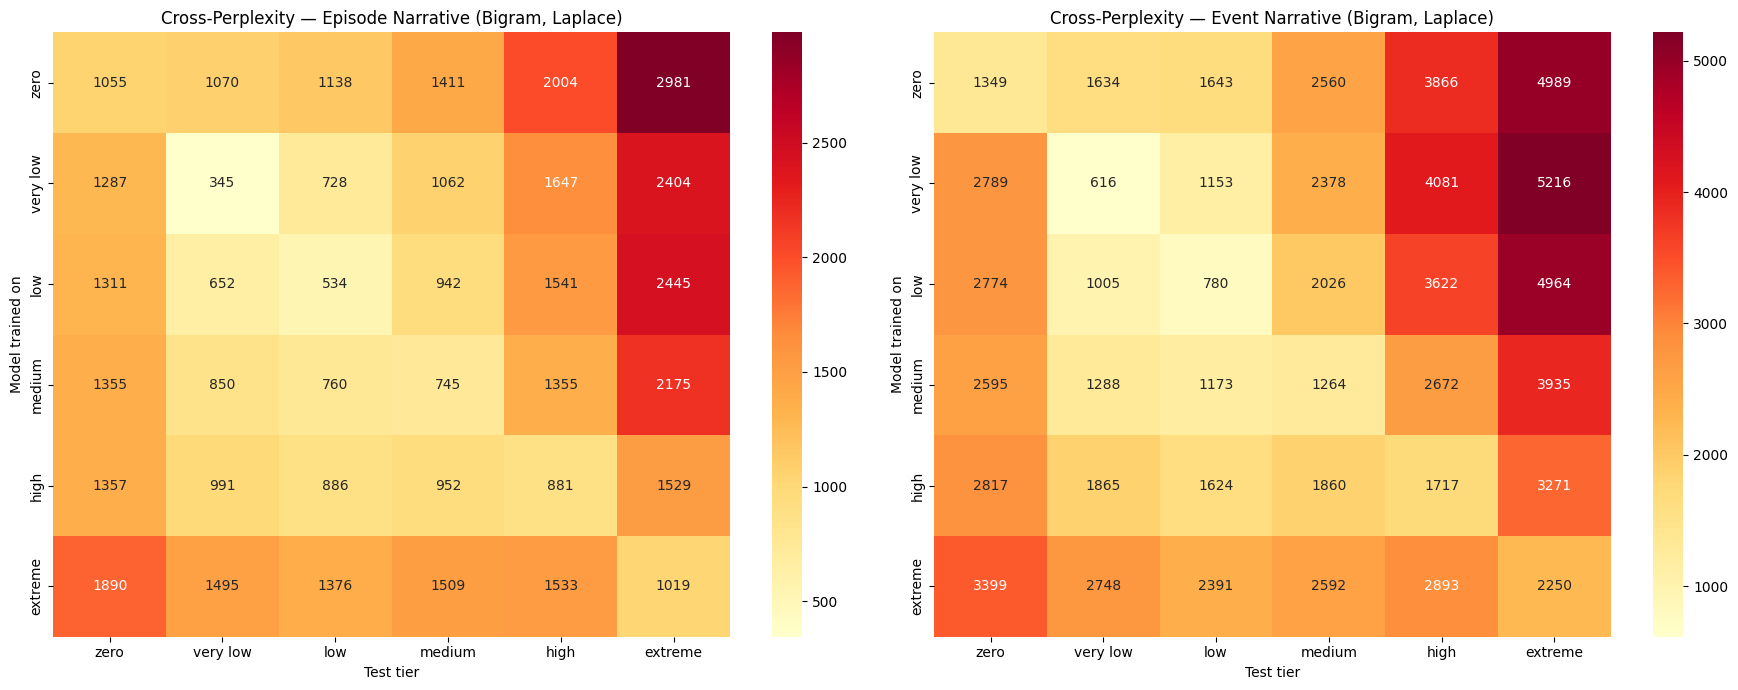

In [46]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

for ax, matrix, title in [
    (ax1, ep_perp, "Episode Narrative"),
    (ax2, ev_perp, "Event Narrative"),
]:
    sns.heatmap(
        pd.DataFrame(matrix, index=tier_names, columns=tier_names),
        annot=True, fmt=".0f", cmap="YlOrRd", ax=ax
    )
    ax.set_xlabel("Test tier")
    ax.set_ylabel("Model trained on")
    ax.set_title(f"Cross-Perplexity — {title} (Bigram, Laplace)")

plt.tight_layout()
plt.show()

In [47]:
ep_ratio_0_5 = ep_perp[0, 5] / ep_perp[0, 0]
ev_ratio_0_5 = ev_perp[0, 5] / ev_perp[0, 0]

print(f"The zero-damage-tier model trained on episode_narrative is {ep_ratio_0_5} times more surprised to see the text in the extreme-damage-tier than its own text.")
print(f"The zero-damage-tier model trained on event_narrative is {ev_ratio_0_5} times more surprised to see the text in the extreme-damage-tier than its own text.")

ep_ratio_3_5 = ep_perp[3, 5] / ep_perp[3, 3]
ev_ratio_3_5 = ev_perp[3, 5] / ev_perp[3, 3]

print(f"The medium-damage-tier model trained on episode_narrative is {ep_ratio_3_5} times more surprised to see the text in the extreme-damage-tier than its own text.")
print(f"The medium-damage-tier model trained on event_narrative is {ev_ratio_3_5} times more surprised to see the text in the extreme-damage-tier than its own text.")

The zero-damage-tier model trained on episode_narrative is 2.8251930886643333 times more surprised to see the text in the extreme-damage-tier than its own text.
The zero-damage-tier model trained on event_narrative is 3.6985345859654766 times more surprised to see the text in the extreme-damage-tier than its own text.
The medium-damage-tier model trained on episode_narrative is 2.9206155147877824 times more surprised to see the text in the extreme-damage-tier than its own text.
The medium-damage-tier model trained on event_narrative is 3.1127784089046595 times more surprised to see the text in the extreme-damage-tier than its own text.


Looking at the perplexity heatmap, we can conclude that the **language used in "High" and "Extreme" damage-tier text is different from the language used in text from lower tiers of damage.**

Notice there is a **slight difference in the perplexity scores from models trained on `episode_narrative` and on `event_narrative`.** **This is probably not surprising, since `episode_narrative` is on average a longer description with greater technical detail, such as the description of the full storm system, and `event_narrative` is often a shorter local description of the event and its effects.** The difference in length of each document might already account for some of this difference in the perplexity score, since a longer document will increase the likelihood of generating richer text just by itself.

However, we have seen from the bigrams that the **nature of the text is also different**, with "Power line" and "Mobile home" being common bigrams in `event_narrative` but not at all in `episode_narrative`. **Perhaps the textual description of a local event is inherently more sparse** - i.e. it can contain more words and expressions depending on the context of the event - **compared to the technical language used in `episode_narrative` which is more self-contained.** This could also contribute to the higher perplexity scores within `event_narrative` trained models.

In general, we can conclude this is ***a good indicator for us to be able to move toward our goal of finding whether extreme weather events are becoming more common thru the years just from textual description alone.***

### 3.5 TF-IDF

In [48]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

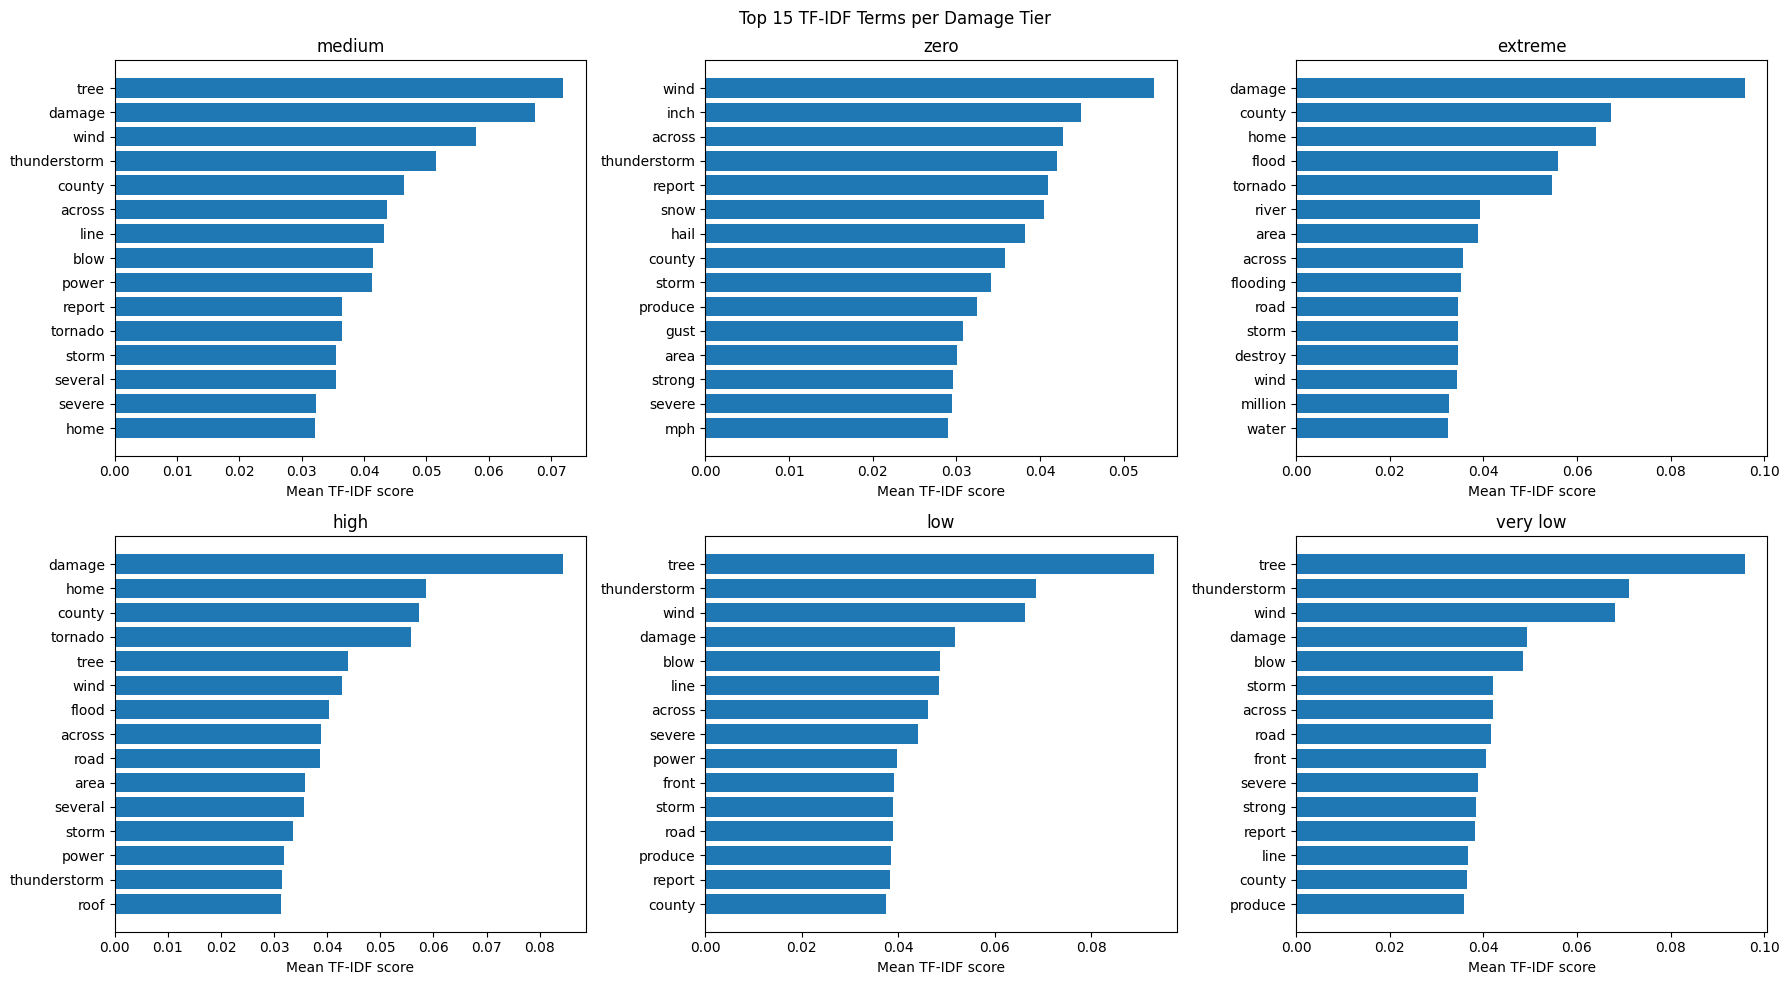

In [49]:
# clean_text is already lemmatized and stopword-filtered — no need to re-run custom_tokenizer_lemmatizer
tfidf = TfidfVectorizer(lowercase=False, min_df=1e-3)
X = tfidf.fit_transform(df["clean_text"])

# Average TF-IDF score per term per tier (kept sparse)
feature_names = tfidf.get_feature_names_out()
top_terms = pd.DataFrame(
    {tier: np.asarray(X[df["damage_tier_label"].values == tier].mean(axis=0)).flatten()
     for tier in df["damage_tier_label"].unique()},
    index=feature_names
).T

# Plot top 15 terms per tier
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, tier in enumerate(top_terms.index):
    top = top_terms.loc[tier].nlargest(15)
    axes[i].barh(top.index[::-1], top.values[::-1])
    axes[i].set_title(tier)
    axes[i].set_xlabel("Mean TF-IDF score")
plt.suptitle("Top 15 TF-IDF Terms per Damage Tier")
plt.tight_layout()
plt.show()

In [50]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import classification_report

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"], df["damage_tier"],
    test_size=0.2, random_state=42, stratify=df["damage_tier"]
)

pipe = Pipeline([
    ("tfidf", TfidfVectorizer(lowercase=False, min_df=1e-3)),
    ("clf",   LogisticRegression(max_iter=int(1e4), solver="liblinear"))
])

grid = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "clf__C": [5, 10, 50],
}
tfidf_logistic_cv = GridSearchCV(pipe, grid, scoring="accuracy",
                  cv=KFold(n_splits=3, shuffle=True, random_state=42),
                  n_jobs=-1)
tfidf_logistic_cv.fit(X_train, y_train)

print("Best params:", tfidf_logistic_cv.best_params_)
print(classification_report(y_test, tfidf_logistic_cv.predict(X_test),
                             target_names=list(TIER_LABELS.values())))

/home/vitor/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/home/vitor/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/home/vitor/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which sup

Best params: {'clf__C': 50, 'tfidf__ngram_range': (1, 2)}
              precision    recall  f1-score   support

        zero       0.84      0.95      0.89    110618
    very low       0.58      0.24      0.34      2766
         low       0.58      0.46      0.52     21014
      medium       0.49      0.33      0.39     16108
        high       0.45      0.19      0.27      4752
     extreme       0.54      0.31      0.40      1775

    accuracy                           0.78    157033
   macro avg       0.58      0.41      0.47    157033
weighted avg       0.75      0.78      0.75    157033



We ran a gridsearch on unigrams and bigrams - `tfidf__ngram_range` - and the conclusion was that the best performing model made use of bigrams.

Higher logistic classifier C was associated with a better model.

In [52]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score

In [54]:
best_model = tfidf_logistic_cv.best_estimator_
y_hat = best_model.predict(X_test)
accuracy_score(y_test, y_hat)

0.7773588990849057

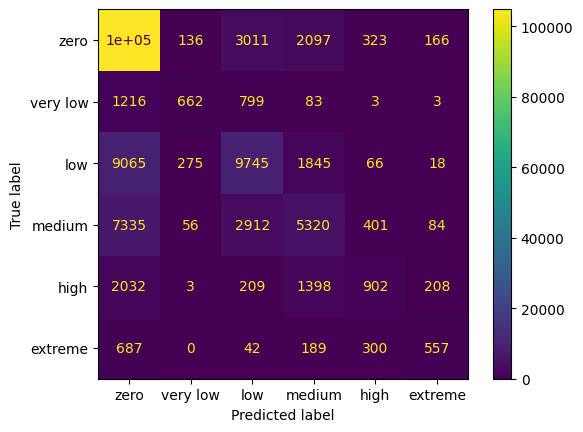

In [55]:
cm = confusion_matrix(y_test, y_hat)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(TIER_LABELS.values())).plot()
plt.show()

**The capacity to predict the `damage_tier` from the text alone is far from perfect using bag-of-words and TF-IDF.**

We can see that the classifier trained on 80% of our `train.csv` document and tested on the remaining 20% has a somewhat diagonal confusion matrix, but with some spillover on tiers neighbouring the diagonal and a concerning albeit expected behaviour on the zero tier.

Concretely, tiers above "Zero" are often correctly identified, but are also often mislabeled as the tier above or below the true one. "Medium" is a good example where the prediction of "Medium" is correct 5320 times, but wrong more than 3000 times in which the correct label was either "Low" or "High".

Furthermore, all tiers are commonly wrongly predicted while its true label is actually "Zero". This might stem from:

- Overrepresentation of "Zero" damage tier in the training - not only does the majority of the data pertain to "Zero" damage events, but we also split the `damage_tiers` in equal thresholds which lead to an overrepresentation of "Zero" damage tier.
- **Lack of context comprehension in TF-IDF BoW** which brings us to the next section, using `word2vec`.

### 4 Text embeddings

In [56]:
import multiprocessing
from gensim.models.phrases import Phrases, FrozenPhrases, ENGLISH_CONNECTOR_WORDS
from gensim.models import Word2Vec, KeyedVectors

In [57]:
cores = multiprocessing.cpu_count()

corpus_tok = df["full_tokens"].tolist()

# Detecting commonly paired words - might be uselful cuz weather data has many two-word expressions - flash flood, forest fire, hail storm, etc etc #
phrases = Phrases(corpus_tok, min_count=30, connector_words=ENGLISH_CONNECTOR_WORDS)
phraser = FrozenPhrases(phrases)
del phrases
corpus_phrased = [phraser[doc] for doc in corpus_tok]

In [70]:
phraser[["hail", "storm", "occurred", "yesterday"]]

['hail', 'storm', 'occurred', 'yesterday']

In [68]:
phraser[["wild", "fire", "occurred", "yesterday"]]

['wild_fire', 'occurred', 'yesterday']

In [69]:
phraser[["flash", "flood", "occurred", "yesterday"]]

['flash', 'flood', 'occurred', 'yesterday']

While some of the terms we expected to see concatenated were indeed concatenated - e.g. wild fire - most of the meteoreology specific terms actually appear too often on their own - e.g. flood - with respect to how many times they appear as a common pair - e.g. flash flood - and therefore did not meet the threshold to be counted as a common pairing.

In [63]:
from collections import Counter
bigrams = [(" ".join(corpus_tok[i][j:j+2])) for i in range(len(corpus_tok)) for j in range(len(corpus_tok[i])-1)]
Counter(bigrams).most_common(30)

[('wind gust', 197746),
 ('cold front', 172619),
 ('severe thunderstorm', 139398),
 ('low pressure', 113045),
 ('large hail', 108034),
 ('thunderstorm develop', 101951),
 ('wind damage', 96979),
 ('heavy rain', 90422),
 ('power line', 89393),
 ('flash flooding', 83816),
 ('upper level', 81385),
 ('strong wind', 80624),
 ('morning hour', 77419),
 ('move across', 74728),
 ('evening hour', 74382),
 ('early morning', 73572),
 ('inch snow', 68130),
 ('damage wind', 65379),
 ('size hail', 65330),
 ('thunderstorm wind', 63893),
 ('heavy rainfall', 62114),
 ('storm produce', 61710),
 ('tree power', 57153),
 ('shower thunderstorm', 56796),
 ('across area', 54516),
 ('damaging wind', 52476),
 ('high wind', 52321),
 ('thunderstorm produce', 52304),
 ('late afternoon', 52108),
 ('severe weather', 51950)]

In [67]:
phrased_vocab = set(tok for doc in corpus_phrased for tok in doc)
original_vocab = set(tok for doc in corpus_tok for tok in doc)

phrases_found = sorted([tok for tok in phrased_vocab if "_" in tok])
print(f"{len(phrases_found)} phrases found:")
print(phrases_found)

14259 phrases found:
['0000_0900cst', '0000_pst', '0000cst_15th', '003_nantucket', '00z_sounding', '0100_0230', '0100_cst', '0100_mdt', '0100cst_16th', '0100e_23rd', '010104_0514', '0102_chance', '010_020', '010_025', '01_02', '01_annual', '01_kilometer', '01_km', '01km_helicity', '01km_srh', '0200_54', '0235_business', '0240_55', '025_050', '025_060', '025_075', '02_03', '02_annual', '0300_cst', '0300_pst', '0315_pst', '0330_cst', '0330_pdt', '0330_pst', '03_km', '0400_pst', '041600_pst', '0430_pdt', '0430cst_1200cst', '0445e_24th', '0500_pst', '050_075', '0530_pst', '0530z_respectively', '05_inchcarroll', '05_inchgwinnett', '05_inchjefferson', '05_inchlumpkin', '05_inchmorgan', '05_inchpolk', '05_inchspalding', '05_widespreadimpacts', '0600_cst', '0600_pst', '0600cst_december', '0630_pdt', '06_07', '06_kilometer', '06_km', '06km_bulk', '06km_layer', '06km_shear', '0700_0730', '0700_akst', '0700_est', '0700_pst', '0700_utc', '0700cst_10002000', '070500_pst', '075_150', '07���_diameter

Nonetheless, over 10k common phrases were found and despite the majority not being metereology related, they help reduce the amount of information.

Now we assign a 150-dimensional vector to the tokens of our dataframe.

**We use skip-gram (`sg=1`)** instead of CBoW (`sg=0`) **due to the more specialized nature of the corpus** - meteorological words will appear less than common english words but we actually want a good and distinct vector representation between different words related to the meteorological events. **Skip-gram seems to be a better choice, perhaps because it predicts context given a target word rather the other way around, and given that our corpus is very specific to meteorology and urban/housing damages, predicting the target word given context could make the representation of the more rare meteorological terms to not be as meaningful in vector space.**

In [71]:
w2v = Word2Vec(
    corpus_phrased,
    vector_size=150, window=5, min_count=5,
    sg=1,  # skip-gram: better for specialised/smaller corpora
    negative=5, ns_exponent=0.75,
    alpha=0.025, min_alpha=0.0001,
    workers=cores - 1, epochs=30
)
w2v.wv.save("nws_word2vec.kv")

In [82]:
DAMAGE_PROBES = ["flood", "tornado", "fire", "damage", "structure", "home", "infrastructure", "road"]

for word in DAMAGE_PROBES:
    if word in w2v.wv:
        neighbours = w2v.wv.most_similar(word, topn=8)
        print(f"\n{word}: {[w for w, _ in neighbours]}")

# Direct similarity comparisons
print(w2v.wv.similarity("apartment", "home"))
print(w2v.wv.similarity("flood", "fire"))


flood: ['flooding', 'flooded', 'overflow_bank', 'inundate', 'floodwaters', 'overflow', 'underwater', 'fm2673']

tornado: ['touch', 'ef0', 'ef1', 'ef2', 'touchdown', 'rat_ef0', 'briefly_touch', 'path_length']

fire: ['wildfire', 'blaze', 'brush_fire', 'consume', 'grass_fire', 'burn', 'containment', 'humancaused']

damage: ['structural', 'damaging', 'property', 'destroy', 'damge', 'outrightdemolished', 'damagea', 'destroyed']

structure: ['outbuilding', 'destroy', 'home', 'building', 'categorize_affected', 'totally_destroyed', 'residence', 'contain_0']

home: ['residence', 'house', 'mobile_home', 'business', 'apartment_complex', 'apartment', 'destroy', 'subdivision']

infrastructure: ['million', 'property', 'repairplease', 'loss_439', 'infastructure', 'million_dollar', 'bridgesculverts', 'repair_cost']

road: ['lane', 'roadway', 'impassable', 'roads', 'va625', 'va653', 'va702', 'rd']
0.6546337
0.24320716


**We can already see the contextual nature of the embeddings, with words like "appartment" and "home", being a lot more similar in vector space than words like "flood" and "fire".**

Now, for each document, we average the vector representations of the tokens in that document, thus creating one vector per event/entry in our dataframe.

In [84]:
def document2vec(tokens, wv, phraser=None):
    if phraser:
        tokens = phraser[tokens]
    try:
        return wv.get_mean_vector(keys=tokens, ignore_missing=True)
    except ValueError:
        return np.zeros(wv.vector_size)

df["doc_embedding"] = df["full_tokens"].apply(
    lambda toks: document2vec(toks, w2v.wv, phraser=phraser)
)

In [90]:
dates = pd.to_datetime(df["begin_date_time"], format="%d-%b-%y %H:%M:%S", errors="coerce")

print("Failed to parse:", dates.isna().sum())

df["year"] = dates.dt.year

Failed to parse: 0


In [91]:
df.head()

,id,event_type,episode_narrative,event_narrative,damage,begin_date_time,cz_timezone,state,full_text,text_length,...,episode_clean,event_tokens,event_clean,full_tokens,clean_text,damage_tier,damage_tier_label,doc_embedding,emb_cluster,year
0,347570,Flash Flood,Tropical Storm Lee formed from a persistent lo...,The Dade County Emergency Management Director ...,10000.0,05-SEP-11 14:30:00,EST-5,GEORGIA,Tropical Storm Lee formed from a persistent lo...,2761,...,tropical storm lee form persistent low pressur...,"[dade, county, emergency, management, director...",dade county emergency management director repo...,"[tropical, storm, lee, form, persistent, low, ...",tropical storm lee form persistent low pressur...,3,medium,"[0.048177507, -0.039272245, 0.026658213, -0.01...",1,2011
1,1054380,Marine Thunderstorm Wind,Scattered thunderstorms moved across portions ...,A wind gust to 36 knots was measured at the Mo...,0.0,20-SEP-22 17:19:00,CST-6,LAKE MICHIGAN,Scattered thunderstorms moved across portions ...,157,...,scattered thunderstorm move across portion sou...,"[wind, gust, 36, knot, measure, montrose, harb...",wind gust 36 knot measure montrose harbor light,"[scattered, thunderstorm, move, across, portio...",scattered thunderstorm move across portion sou...,0,zero,"[0.032467205, -0.0071488554, 0.004042103, -0.0...",0,2022
2,317977,Thunderstorm Wind,"During the evening hours on July 19th, a sever...",Numerous trees and power lines were downed acr...,50000.0,19-JUL-11 22:45:00,EST-5,KENTUCKY,"During the evening hours on July 19th, a sever...",445,...,evening hour july 19th severe thunderstorm bri...,"[numerous, tree, power, line, across, western,...",numerous tree power line across western portio...,"[evening, hour, july, 19th, severe, thundersto...",evening hour july 19th severe thunderstorm bri...,3,medium,"[0.069358975, -0.055302933, 0.018035559, -0.01...",4,2011
3,509299,High Wind,An upper-level trough moved through southern C...,The Big Black Mountain mesonet recorded a peak...,0.0,26-APR-14 01:00:00,PST-8,CALIFORNIA,An upper-level trough moved through southern C...,589,...,upperlevel trough move southern california str...,"[big, black, mountain, mesonet, record, peak, ...",big black mountain mesonet record peak wind gu...,"[upperlevel, trough, move, southern, californi...",upperlevel trough move southern california str...,0,zero,"[-0.006983442, -0.010203843, -0.015449373, -0....",0,2014
4,1009291,Hail,A small cluster of thunderstorms developed nor...,Quarter size hail fell near Rural.,0.0,12-APR-22 16:16:00,CST-6,WISCONSIN,A small cluster of thunderstorms developed nor...,335,...,small cluster thunderstorm develop north warm ...,"[quarter, size, hail, fell, near, rural]",quarter size hail fell near rural,"[small, cluster, thunderstorm, develop, north,...",small cluster thunderstorm develop north warm ...,0,zero,"[0.06823363, -0.024101095, 0.008898128, -0.015...",1,2022


We will look at **6 clusters of the document-averaged embedding vectors and see their evolution over the years. We cluster them in six in the initial naive hope that they could somewhat match the 6 damage tiers and give a clean interpretation of evolution of damage thru time - of course, that will not be possible**, because the embeddding representation of the vectors contains so much more information than just the damage inflicted by the weather event.

<Axes: title={'center': 'Narrative cluster distribution over time'}, xlabel='year'>

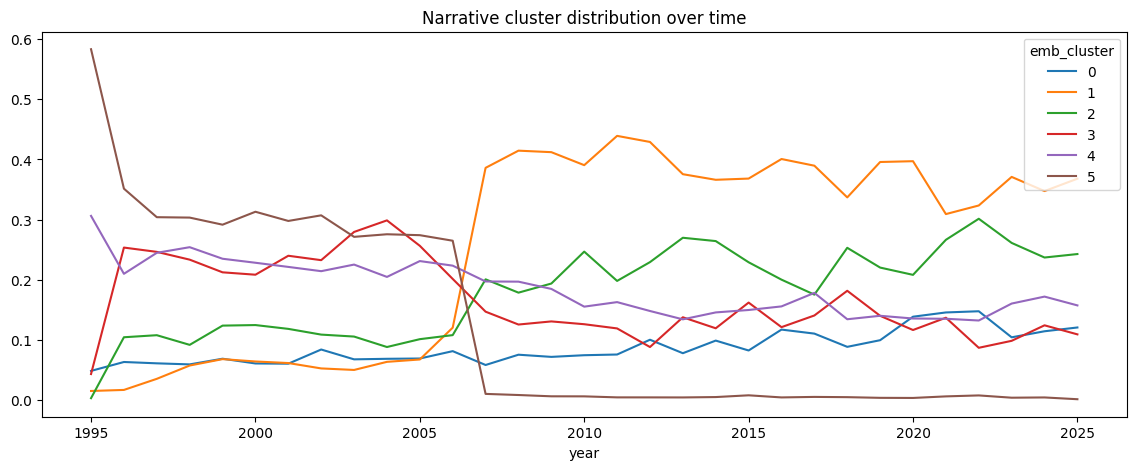

In [93]:
from sklearn.cluster import KMeans
import numpy as np

X_emb = np.stack(df["doc_embedding"].values)
km = KMeans(n_clusters=6, random_state=42, n_init=10)
df["emb_cluster"] = km.fit_predict(X_emb)

# Track cluster distribution by year
df.groupby("year")["emb_cluster"].value_counts(normalize=True).unstack().plot(
    figsize=(14, 5), title="Narrative cluster distribution over time"
)

In [98]:
print(df.groupby("emb_cluster")["damage_tier"].value_counts(normalize=True).unstack().fillna(0).round(2))

damage_tier     0     1     2     3     4     5
emb_cluster                                    
0            0.90  0.01  0.05  0.04  0.01  0.00
1            0.64  0.03  0.21  0.10  0.02  0.00
2            0.93  0.00  0.02  0.03  0.01  0.01
3            0.67  0.01  0.09  0.12  0.06  0.04
4            0.59  0.02  0.16  0.15  0.05  0.02
5            0.41  0.03  0.26  0.24  0.05  0.01


A simple look at the percentage of each `damage_tier` event in each cluster does not reveal much information. This is not unexpected as "Zero" already dominates the data from the beginning.

In [107]:
top15 = df["event_type"].value_counts().head(20).index
print(df[df["event_type"].isin(top15)].groupby("emb_cluster")["event_type"]
      .value_counts(normalize=True).unstack().fillna(0).round(2))

event_type   Blizzard  Dense Fog  Drought  Extreme Cold/Wind Chill  \
emb_cluster                                                          
0                0.01       0.00     0.00                     0.01   
1                0.00       0.00     0.00                     0.00   
2                0.03       0.02     0.14                     0.03   
3                0.00       0.00     0.01                     0.00   
4                0.00       0.00     0.00                     0.00   
5                0.00       0.00     0.00                     0.00   

event_type   Flash Flood  Flood  Funnel Cloud  Hail  Heat  Heavy Rain  \
emb_cluster                                                             
0                   0.00   0.00          0.00  0.01  0.00        0.00   
1                   0.07   0.02          0.01  0.22  0.00        0.02   
2                   0.02   0.03          0.00  0.01  0.03        0.05   
3                   0.46   0.28          0.00  0.02  0.00        0.06   
4

A similar look into the percentage of each `event_type` in each cluster is also not revealing of much information. In fact, clusters 0, 1, 4 and 5 all have a high response to "Thunderstorm wind", despite their very different behaviour over time.

In [105]:
for cluster_id in range(6):
    texts = df[df["emb_cluster"] == cluster_id]["clean_text"]
    print(f"\nCluster {cluster_id}:", texts.str.split().explode().value_counts().head(10).index.tolist())


Cluster 0: ['wind', 'mph', 'gust', 'strong', 'across', 'high', 'thunderstorm', 'report', 'measure', 'produce']

Cluster 1: ['wind', 'thunderstorm', 'across', 'storm', 'severe', 'front', 'produce', 'strong', 'damage', 'move']

Cluster 2: ['inch', 'snow', 'across', 'county', 'area', 'low', 'report', 'wind', 'heavy', 'snowfall']

Cluster 3: ['flood', 'county', 'inch', 'flooding', 'road', 'rain', 'river', 'water', 'across', 'heavy']

Cluster 4: ['damage', 'county', 'wind', 'tree', 'tornado', 'hail', 'report', 'thunderstorm', 'storm', 'across']

Cluster 5: ['tree', 'blow', 'damage', 'power', 'wind', 'line', 'several', 'report', 'thunderstorm', 'county']


However, now we have something interesting from looking at the top TF-IDF terms per cluster.

**Cluster 0 aligns highly to "High Wind", "Marine Thunderstorm Wind" and "Thunderstorm Wind"**. Furthermore, **its top terms pertain to "wind", "gust", "mph"**. At the same time, **it pertains 90% of the time to "Zero" damage**. This means it is likely a **cluster of events with low damage and characterized by windy conditions**.

**Cluster 1 aligns highly to "Thunderstorm Wind" and "Hail". Top terms include those exact words**, "wind", "thunderstorm", "storm", but they also **include "severe" and "damage"**. which cluster 0 did not. This is **further confirmed by 31% of the cluster pertaining to damage tiers "Low" and "Medium"**.

**Cluster 2 aligns highly with "Winter Storm" and "Winter Weather", and the top words include "snow" and "inch". The damage is lower, as seen by the 93% of "Zero" damage events** and the absence of relevant words in the top ranking. It makes sense, since snow is less damaging than other extreme weather events.

**Cluster 3 aligns highly with "Flash Flood" and "Flood", with the top words reinforcing that: "flood", "road", "rain", "river", "water"**. Damages are greater.

**Cluster 4 and cluster 5 align more "Thunderstorm Wind", "Tornado" and "Hail"**. What's more interesting perhaps is that **they also care more about words that seem to describe the effects of the events rather than the meteorology itself - "damage", "county", "tree", "blow", "power"** - which is **a sign of more damaging events**, confirmed by the lowest percentage - **41% in cluster 5 - of "Zero" damage events** out of all the clusters.

However, it's unfortunately clear that we cannot obtain great conclusions from the trend of the clusters. Cluster 4 and 5 pertain more to damaging events, but decrease over time. However, we notice that there is a sharp jump in clusters 1 and cluster 5 around 2006-2007. We notice in the cell below that it is actually a data artifact driven by a sharp increase in the number of events recorded after 2006-2007.

<Axes: title={'center': 'Number of events recorded per year'}, xlabel='year'>

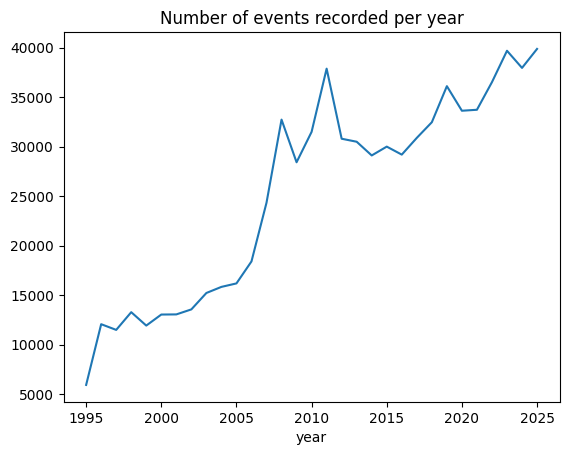

In [108]:
df.groupby("year").size().plot(title="Number of events recorded per year")

<Axes: title={'center': 'Narrative cluster distribution over time (2008–)'}, xlabel='year'>

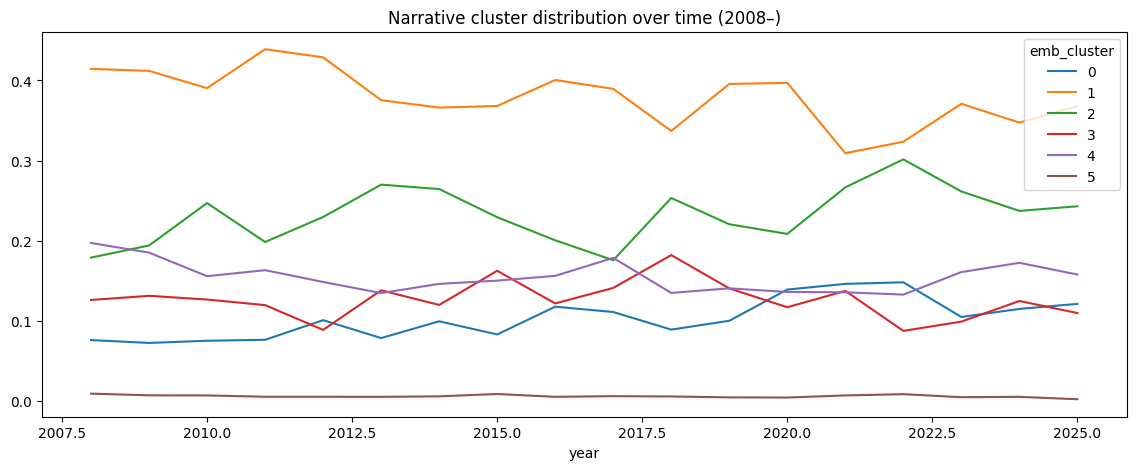

In [109]:
df_post2008 = df[df["year"] >= 2008]

df_post2008.groupby("year")["emb_cluster"].value_counts(normalize=True).unstack().plot(
    figsize=(14, 5), title="Narrative cluster distribution over time (2008–)"
)

<Axes: title={'center': 'Absolute number of high-damage events over time'}, xlabel='year'>

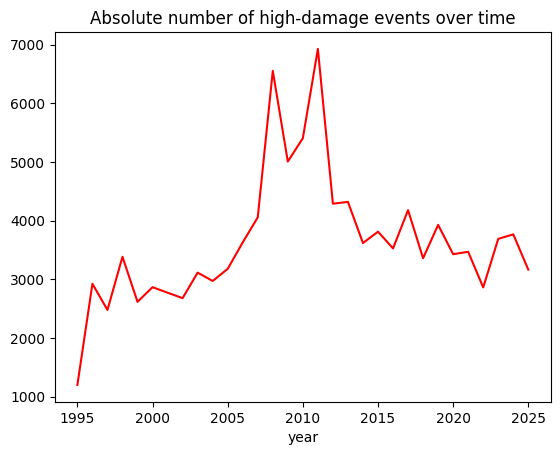

In [144]:
df.groupby("year")["damage_tier"].apply(lambda x: (x >= 3).sum()).plot(color='red',
    title="Absolute number of high-damage events over time"
)

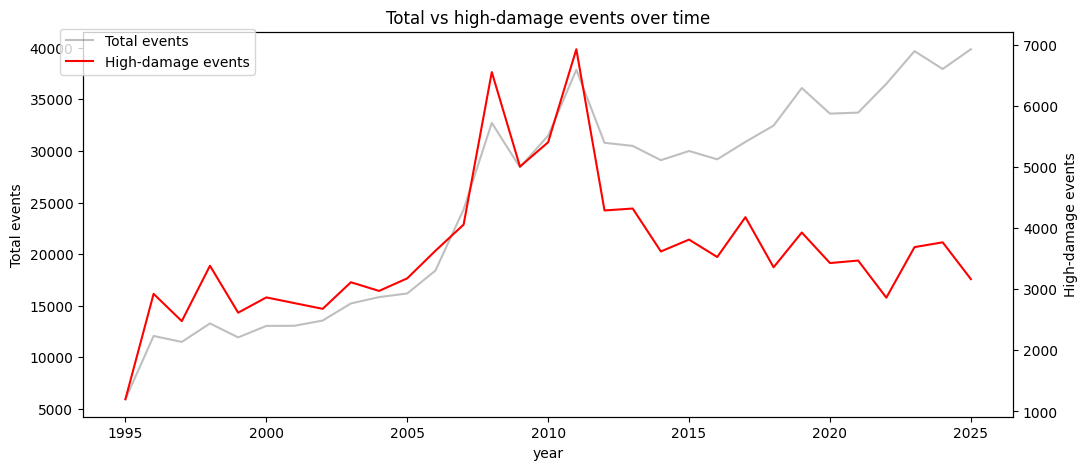

In [219]:
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

df.groupby("year").size().plot(ax=ax1, color="grey", alpha=0.5, label="Total events")
df.groupby("year")["damage_tier"].apply(lambda x: (x >=3).sum()).plot(ax=ax2, color="red", label="High-damage events")

ax1.set_ylabel("Total events")
ax2.set_ylabel("High-damage events")
plt.title("Total vs high-damage events over time")
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
plt.show()

We find it strange that the number of high-damage events was increasing until 2011-2012 and then decreased while the number of total weather events kept increasing.

Below, we use the TF-IDF logistic regressions per year, applying the model to each year's documents and tracking the predicted damage tier distribution. We do not expect anything different from what the true labels show us in the plots above... but we check.

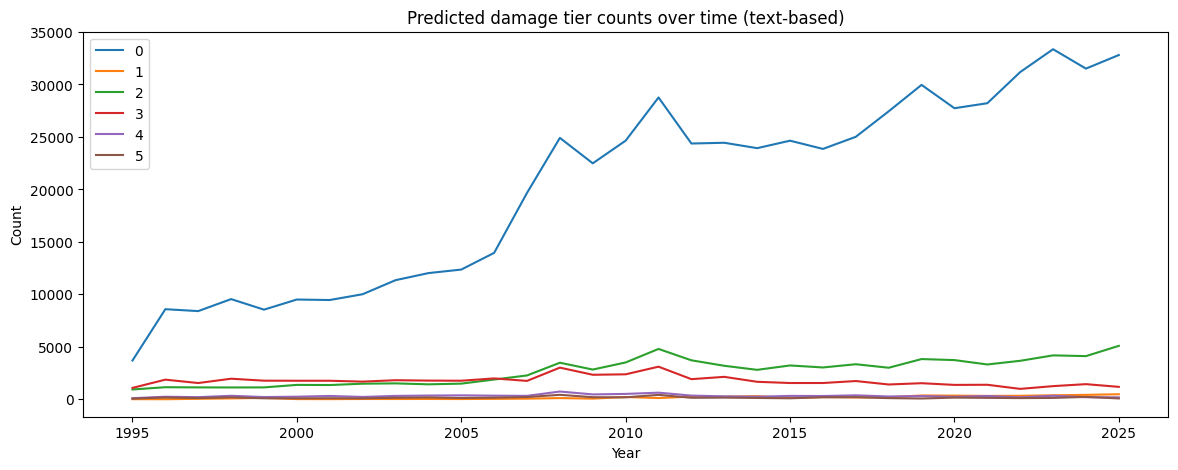

In [143]:
early_pred_abs = (
    df.groupby("year")["clean_text"]
    .apply(lambda texts: pd.Series(best_model.predict(texts)).value_counts())
    .unstack(fill_value=0)
)

early_pred_abs.plot(figsize=(14, 5), title="Predicted damage tier counts over time (text-based)")
plt.ylabel("Count")
plt.xlabel("Year")
plt.show()

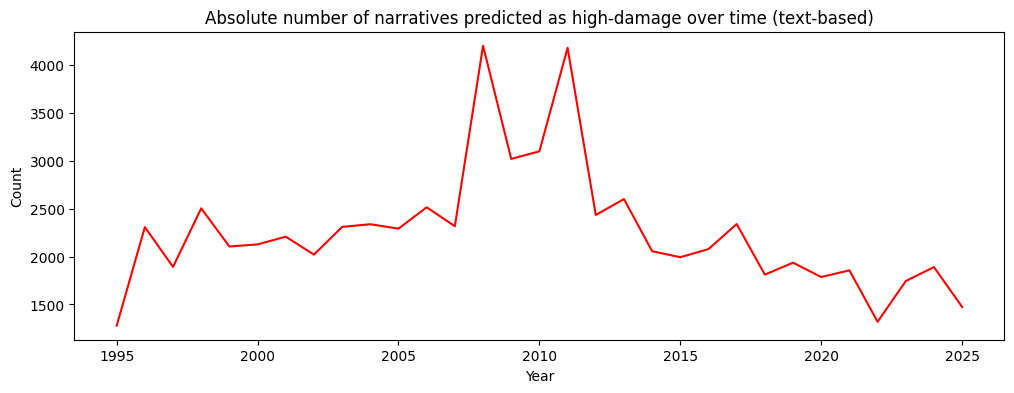

In [173]:
high_damage_pred_abs = early_pred_abs[[3, 4, 5]].sum(axis=1)
high_damage_pred_abs.plot(figsize=(12, 4), color='red', title="Absolute number of narratives predicted as high-damage over time (text-based)")
plt.ylabel("Count")
plt.xlabel("Year")
plt.show()

It's an interesting observation of the capacity of the TF-IDF logistic predictor that the curve looks quite similar, albeit with different absolute counts for each year. And as expected of course it does not show any increase in higher damage events...

We also want to ask another question: **despite the absolute count of events in a high damage tier not increasing past 2012, could this be due to other artifacts - e.g. better infrastructure and preparation to extreme events, greater civilian awareness of risks** and how to mitigate them, all reasons which could lead to extreme events being less damaging financially despite being more agressive from an objective standpoint - however objective text ever is.

For that, **we computed the word2vec representation of a damage vocabulary of our own, and then computed the cosine similarity between the average word2vec representation of each document and the word2vec representation of the damage vocabulary. We computed the mean of the cosine similarity for all documents in each year, and plot below the evolution of this mean cosine similarity across time.**

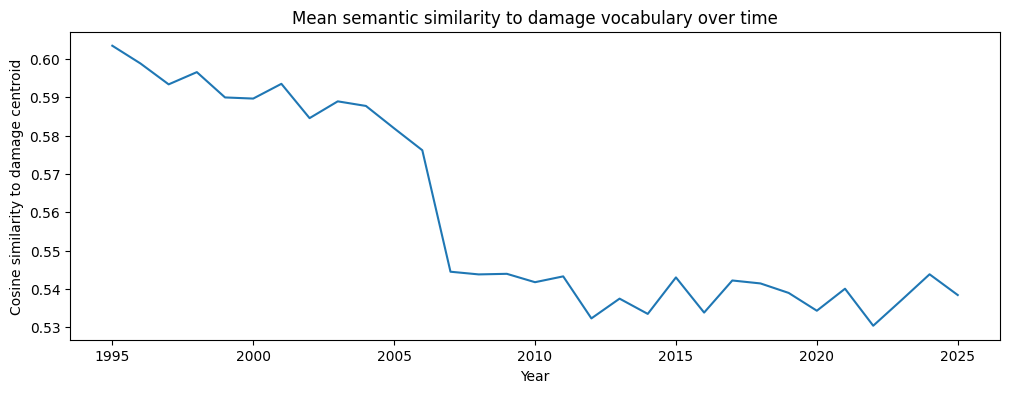

In [196]:
from sklearn.metrics.pairwise import cosine_similarity

# Our damage vocabulary #
damage_keywords = ["agressive", "destroy", "casualty", "injure", "collapse", "cost", 
                   "debris", "loss", "destruction", "fatal", "death", "worst",
                   "structural", "flood", "crush", "devastate", "ruin", "terrible"]

# Damage centroid #
damage_vecs = [w2v.wv.get_vector(w, norm=True) for w in damage_keywords if w in w2v.wv]
damage_centroid = np.mean(damage_vecs, axis=0, keepdims=True)

X_emb = np.stack(df["doc_embedding"].values)
df["damage_similarity"] = cosine_similarity(X_emb, damage_centroid).flatten()

df.groupby("year")["damage_similarity"].mean().plot(
    figsize=(12, 4),
    title="Mean semantic similarity to damage vocabulary over time"
)
plt.ylabel("Cosine similarity to damage centroid")
plt.xlabel("Year")
plt.show()

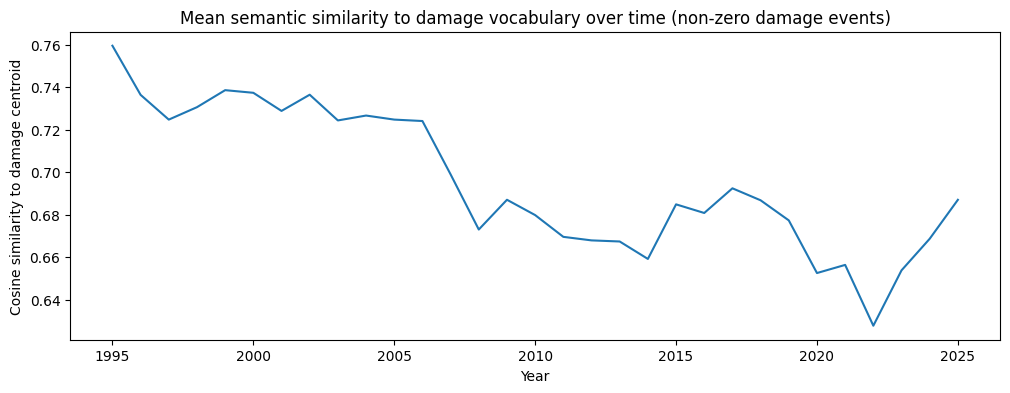

In [197]:
df[df["damage_tier"] == 5].groupby("year")["damage_similarity"].mean().plot(
    figsize=(12, 4),
    title="Mean semantic similarity to damage vocabulary over time (non-zero damage events)"
)
plt.ylabel("Cosine similarity to damage centroid")
plt.xlabel("Year")
plt.show()

Once again, we do not find a clear upward trend in the existence of words pertaining damage, destruction, agressiveness, etc.

### RNN to map text to damage tier

In [148]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, losses, optimizers
import json

vectorize_layer = layers.TextVectorization(
    max_tokens=20000,
    standardize=None,
    output_mode='int',
    output_sequence_length=None   # Variable length for RNN #
)
vectorize_layer.adapt(X_train.to_numpy())

In [149]:
embedding_dim = 150   # matches word2vec vector_size
vocab = vectorize_layer.get_vocabulary(include_special_tokens=True)
embedding_matrix = np.random.uniform(-0.05, 0.05, (len(vocab), embedding_dim))

oov_words = []
for i, w in enumerate(vocab):
    try:
        embedding_matrix[i] = w2v.wv.get_vector(w, norm=True)
    except KeyError:
        embedding_matrix[i] = embedding_matrix[1]
        oov_words.append(w)

print(f"OOV words: {len(oov_words)} / {len(vocab)}")

OOV words: 1490 / 20000


In [150]:
n_classes = df["damage_tier"].nunique()

BLSTM_w2v = tf.keras.Sequential([
    layers.Input(shape=(1,), dtype="string"),
    vectorize_layer,
    layers.Embedding(
        input_dim=len(vocab),
        output_dim=embedding_dim,
        embeddings_initializer=keras.initializers.Constant(embedding_matrix),
        mask_zero=True,
        trainable=False,
        name='embedding'
    ),
    layers.Bidirectional(layers.LSTM(64)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(n_classes, activation='softmax')
], name="BLSTM_w2v")

BLSTM_w2v.summary()

Model: "BLSTM_w2v"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ (None, None)           │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, None, 150)      │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │       110,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,118,726 (11.90 MB)

 Trainable params: 118,726 (463.77 KB)

 Non-trainable params: 3,000,000 (11.44 MB)

In [154]:
import os
os.makedirs("./checkpoints/BLSTM_w2v_frozen", exist_ok=True)
os.makedirs("./checkpoints/BLSTM_w2v_finetuned", exist_ok=True)

In [ ]:
BLSTM_w2v.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss=losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

early_stopping_cb = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, verbose=1)

history_frozen = BLSTM_w2v.fit(
    X_train.to_numpy(), y_train.to_numpy(),
    validation_data=(X_test.to_numpy(), y_test.to_numpy()),
    batch_size=128, epochs=20,
    callbacks=[early_stopping_cb]
)

BLSTM_w2v.save_weights("./checkpoints/BLSTM_w2v_frozen/model.weights.h5")

Epoch 1/20
4908/4908 ━━━━━━━━━━━━━━━━━━━━ 1634s 332ms/step - accuracy: 0.7184 - loss: 0.7609 - val_accuracy: 0.7326 - val_loss: 0.7086
Epoch 2/20
4908/4908 ━━━━━━━━━━━━━━━━━━━━ 1558s 317ms/step - accuracy: 0.7305 - loss: 0.7218 - val_accuracy: 0.7391 - val_loss: 0.6883
Epoch 3/20
4908/4908 ━━━━━━━━━━━━━━━━━━━━ 1558s 317ms/step - accuracy: 0.7374 - loss: 0.7020 - val_accuracy: 0.7452 - val_loss: 0.6725
Epoch 4/20
4908/4908 ━━━━━━━━━━━━━━━━━━━━ 1557s 317ms/step - accuracy: 0.7426 - loss: 0.6880 - val_accuracy: 0.7489 - val_loss: 0.6648
Epoch 5/20
4908/4908 ━━━━━━━━━━━━━━━━━━━━ 1560s 318ms/step - accuracy: 0.7465 - loss: 0.6774 - val_accuracy: 0.7520 - val_loss: 0.6550
Epoch 6/20
4908/4908 ━━━━━━━━━━━━━━━━━━━━ 1562s 318ms/step - accuracy: 0.7504 - loss: 0.6675 - val_accuracy: 0.7563 - val_loss: 0.6446
Epoch 7/20
4908/4908 ━━━━━━━━━━━━━━━━━━━━ 1565s 319ms/step - accuracy: 0.7533 - loss: 0.6591 - val_accuracy: 0.7561 - val_loss: 0.6413
Epoch 8/20
4908/4908 ━━━━━━━━━━━━━━━━━━━━ 1563s 319ms/s

ValueError: The filename must end in `.weights.h5`. Received: filepath=./checkpoints/BLSTM_w2v_frozen/weights.h5

In [156]:
BLSTM_w2v.save_weights("./checkpoints/BLSTM_w2v_frozen/model.weights.h5")

In [157]:
BLSTM_w2v.get_layer('embedding').trainable = True
BLSTM_w2v.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),   # lower LR for fine-tuning
    loss=losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

history_finetune = BLSTM_w2v.fit(
    X_train.to_numpy(), y_train.to_numpy(),
    validation_data=(X_test.to_numpy(), y_test.to_numpy()),
    batch_size=128, epochs=10,
    callbacks=[early_stopping_cb]
)

BLSTM_w2v.save_weights("./checkpoints/BLSTM_w2v_finetuned/model.weights.h5")

Epoch 1/10
 330/4908 ━━━━━━━━━━━━━━━━━━━━ 32:25 425ms/step - accuracy: 0.7836 - loss: 0.5806

KeyboardInterrupt: 

In [159]:
def plot_training(history_dict):
    acc = history_dict['accuracy']
    val_acc = history_dict['val_accuracy']
    loss = history_dict['loss']
    val_loss = history_dict['val_loss']
    
    epochs = range(1, len(loss) + 1)
    
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, 'b--', label='Training')
    plt.plot(epochs, val_loss, 'r-', label='Validation')
    plt.xlabel('Epochs')
    plt.ylabel('Cross-Entropy Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs, acc, 'b--', label='Training')
    plt.plot(epochs, val_acc, 'r-', label='Validation')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    
    plt.show()

4908/4908 ━━━━━━━━━━━━━━━━━━━━ 127s 26ms/step
              precision    recall  f1-score   support

        zero       0.85      0.95      0.90    110618
    very low       0.85      0.01      0.02      2766
         low       0.60      0.46      0.52     21014
      medium       0.49      0.43      0.45     16108
        high       0.45      0.20      0.28      4752
     extreme       0.48      0.27      0.35      1775

    accuracy                           0.78    157033
   macro avg       0.62      0.39      0.42    157033
weighted avg       0.76      0.78      0.76    157033



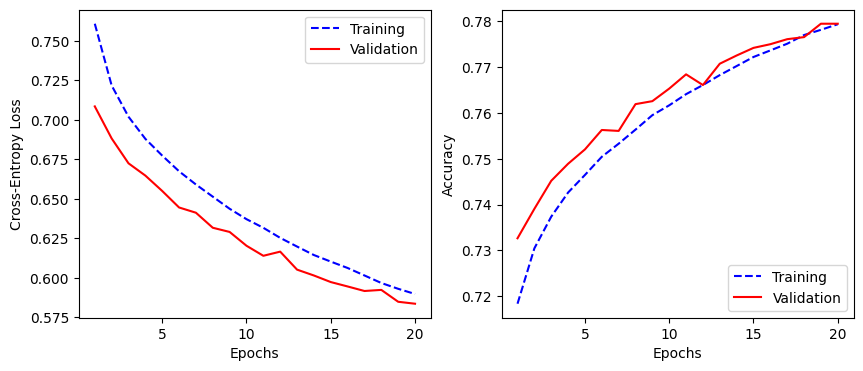

In [ ]:
from sklearn.metrics import classification_report

y_pred = np.argmax(BLSTM_w2v.predict(X_test.to_numpy()), axis=1)
print(classification_report(y_test, y_pred, target_names=list(TIER_LABELS.values())))
plot_training(history_frozen.history)

186/186 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
378/378 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step
360/360 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step
416/416 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step
373/373 ━━━━━━━━━━━━━━━━━━━━ 28s 75ms/step
408/408 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step
409/409 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step
424/424 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step
476/476 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step
495/495 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step
506/506 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step
576/576 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step
761/761 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step
1023/1023 ━━━━━━━━━━━━━━━━━━━━ 26s 25ms/step
888/888 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step
984/984 ━━━━━━━━━━━━━━━━━━━━ 27s 28ms/step
1184/1184 ━━━━━━━━━━━━━━━━━━━━ 39s 33ms/step
963/963 ━━━━━━━━━━━━━━━━━━━━ 27s 28ms/step
953/953 ━━━━━━━━━━━━━━━━━━━━ 27s 28ms/step
910/910 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step
913/913 ━━━━━━━━━━━━━━━━━━━━ 25s 27ms/step
965/965 ━━━━━━━━━━━━━━━━━━━━ 26s 27ms/step
1015/1015 ━━━━━

<Axes: title={'center': 'Absolute high-damage predictions over time (BLSTM + word2vec)'}, xlabel='year'>

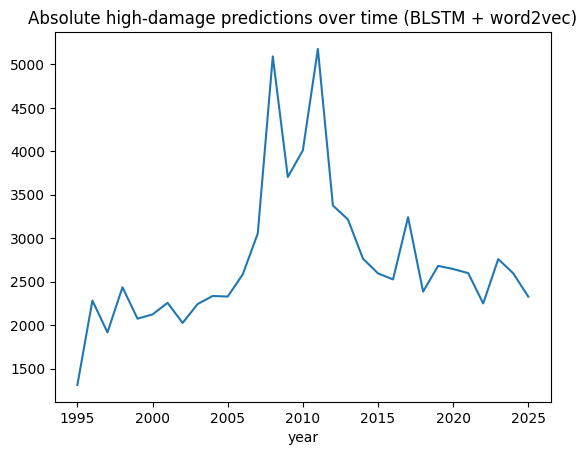

In [162]:
high_damage_neural = (
    df.groupby("year")["clean_text"]
    .apply(lambda texts: (np.argmax(BLSTM_w2v.predict(texts.to_numpy()), axis=1) >= 3).sum())
)
high_damage_neural.plot(title="Absolute high-damage predictions over time (BLSTM + word2vec)")

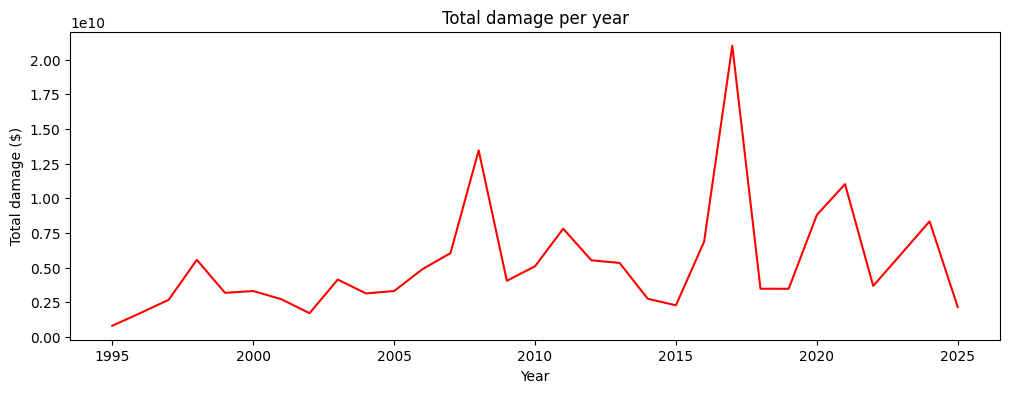

In [180]:
df.groupby("year")[["damage"]].sum().sum(axis=1).plot(
    figsize=(12, 4), color='red',
    title="Total damage per year"
)
plt.ylabel("Total damage ($)")
plt.xlabel("Year")
plt.show()

/tmp/ipykernel_236851/2424032031.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby("year").apply(


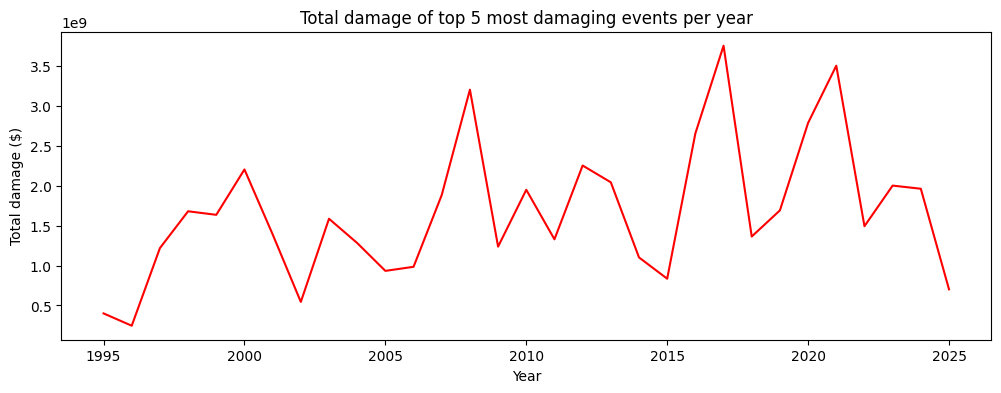

In [192]:
df.groupby("year").apply(
    lambda g: g.nlargest(5, "damage")["damage"].sum()
).plot(
    figsize=(12, 4), color='red',
    title="Total damage of top 5 most damaging events per year"
)
plt.ylabel("Total damage ($)")
plt.xlabel("Year")
plt.show()

/tmp/ipykernel_236851/3214273182.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.nlargest(5, "damage")["damage"].sum())
/tmp/ipykernel_236851/3214273182.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.nlargest(5, "damage")["damage"].sum())
/tmp/ipykernel_236851/3214273182.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is depr

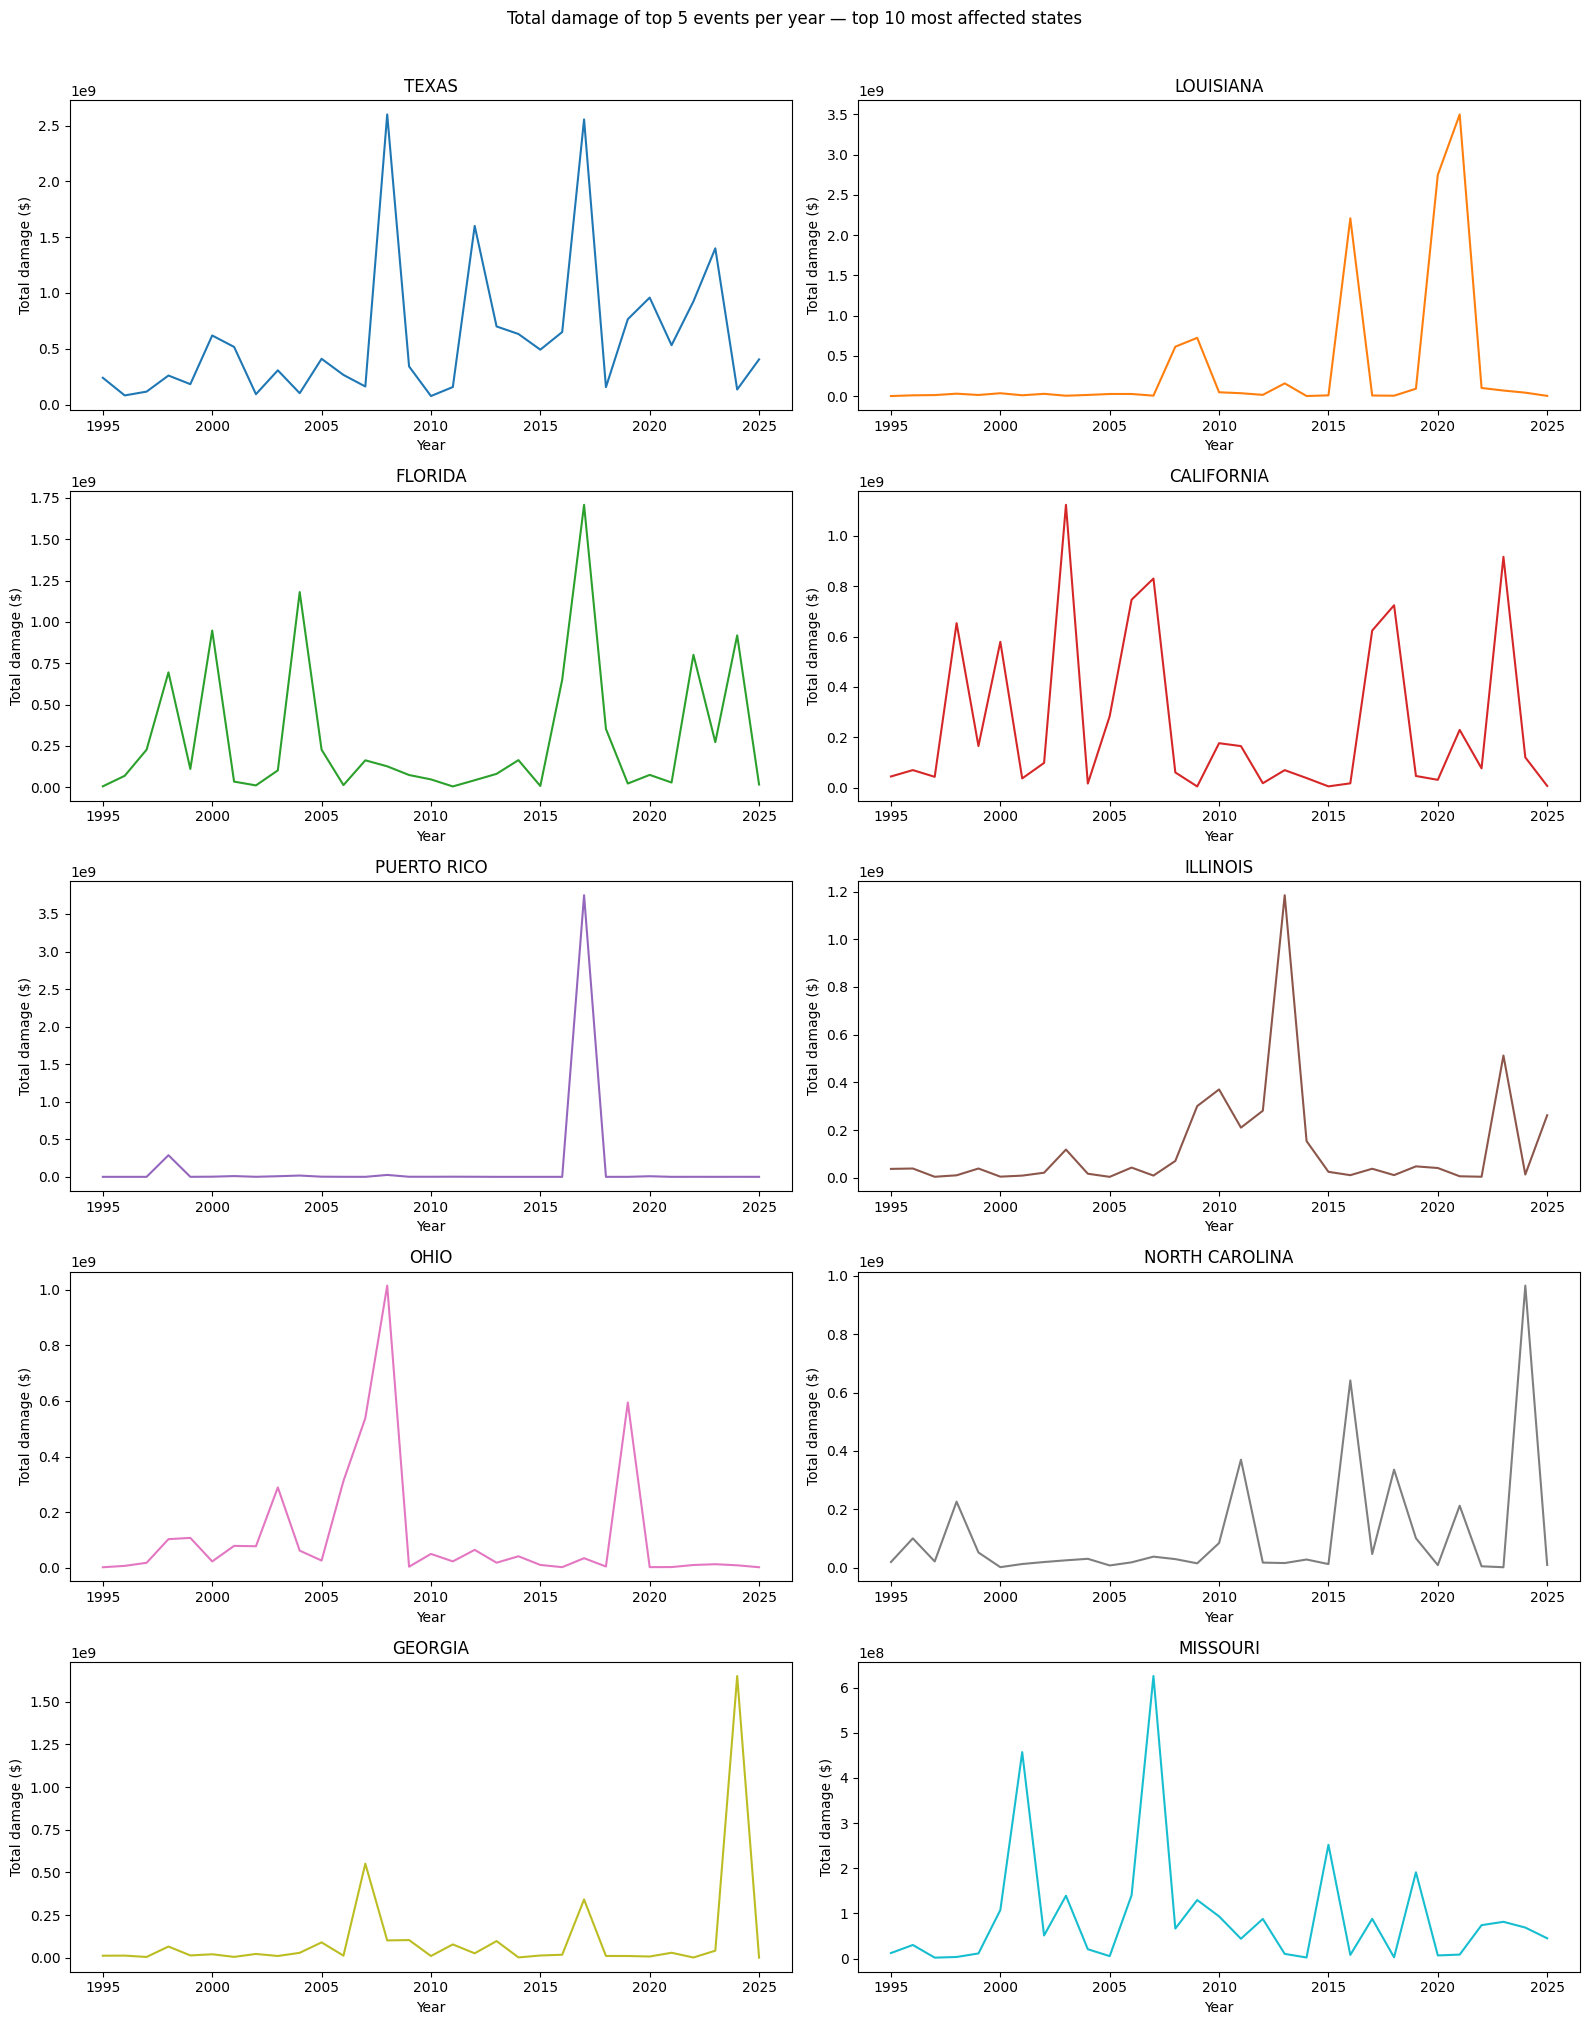

In [191]:
top10_states = (
    df.groupby(["state", "year"])
    .apply(lambda g: g.nlargest(5, "damage")["damage"].sum())
    .groupby("state")
    .sum()
    .nlargest(10)
    .index
)

colors = plt.cm.tab10.colors

fig, axes = plt.subplots(5, 2, figsize=(16, 20))
axes = axes.flatten()

for i, state in enumerate(top10_states):
    (
        df[df["state"] == state]
        .groupby("year")
        .apply(lambda g: g.nlargest(5, "damage")["damage"].sum())
        .plot(ax=axes[i], title=state, color=colors[i])
    )
    axes[i].set_ylabel("Total damage ($)")
    axes[i].set_xlabel("Year")

plt.suptitle("Total damage of top 5 events per year — top 10 most affected states", y=1.01)
plt.tight_layout()
plt.show()

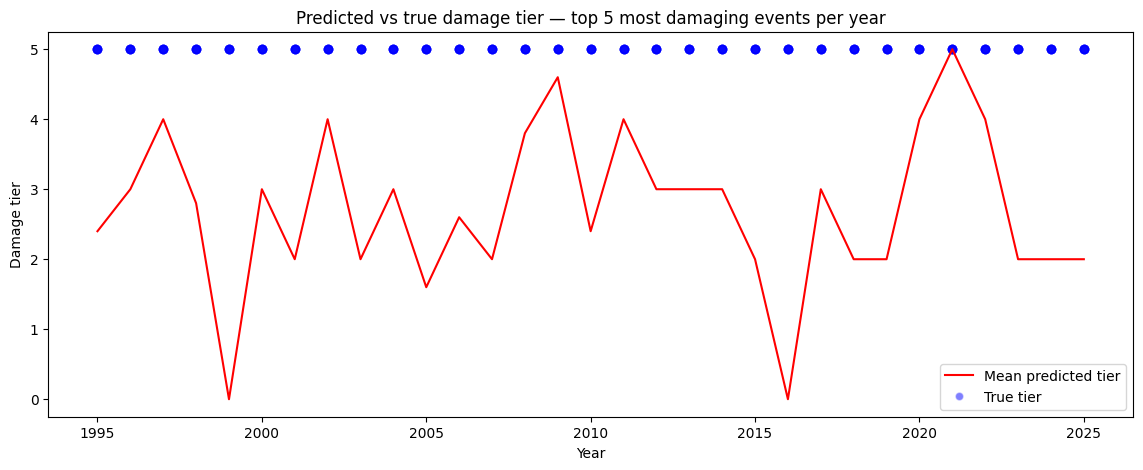

In [200]:
fig, ax = plt.subplots(figsize=(14, 5))

top5_per_year.groupby("year")["neural_pred"].mean().plot(
    ax=ax, color="red", label="Mean predicted tier"
)

for _, group in top5_per_year.groupby("year"):
    ax.scatter(group["year"], group["damage_tier"], color="blue", alpha=0.5)

ax.set_title("Predicted vs true damage tier — top 5 most damaging events per year")
ax.set_ylabel("Damage tier")
ax.set_xlabel("Year")
ax.legend(handles=[
    plt.Line2D([0], [0], color="red", label="Mean predicted tier"),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', alpha=0.5, label="True tier")
])
plt.show()

We have to do something else in order to evaluate extreme weather events - clearly the model is only apt at capturing the lowest "Zero" damage tier, and the 78% accuracy is largely driven by this.

We train the model on the tiers above "Zero" only.

In [211]:
os.makedirs("./checkpoints/BLSTM_damage", exist_ok=True)

In [229]:
df_damage = df[df["damage_tier"] > 0].reset_index(drop=True)
df_damage["damage_tier_remapped"] = df_damage["damage_tier"] - 1 # Output neurons expect 0-4 and we had 1-5 after cutting out the first neuron/tier

X_train_damage, X_test_damage, y_train_damage, y_test_damage = train_test_split(
    df_damage["clean_text"], df_damage["damage_tier_remapped"],
    test_size=0.2, random_state=42, stratify=df_damage["damage_tier_remapped"]
)

n_classes_damage = df_damage["damage_tier"].nunique()

In [230]:
vectorize_layer_damage = layers.TextVectorization(
    max_tokens=20000,
    standardize=None,
    output_mode='int',
    output_sequence_length=None
)
vectorize_layer_damage.adapt(X_train_damage.to_numpy())

In [231]:
embedding_dim = 150

vocab_damage = vectorize_layer_damage.get_vocabulary(include_special_tokens=True)
embedding_matrix_damage = np.random.uniform(-0.05, 0.05, (len(vocab_damage), embedding_dim))

oov_words_damage = []
for i, w in enumerate(vocab_damage):
    try:
        embedding_matrix_damage[i] = w2v.wv.get_vector(w, norm=True)
    except KeyError:
        embedding_matrix_damage[i] = embedding_matrix_damage[1]
        oov_words_damage.append(w)

print(f"OOV words: {len(oov_words_damage)} / {len(vocab_damage)}")

OOV words: 990 / 20000


In [232]:
BLSTM_damage = tf.keras.Sequential([
    layers.Input(shape=(1,), dtype="string"),
    vectorize_layer_damage,
    layers.Embedding(
        input_dim=len(vocab_damage),
        output_dim=embedding_dim,
        embeddings_initializer=keras.initializers.Constant(embedding_matrix_damage),
        mask_zero=True,
        trainable=False,
        name='embedding'
    ),
    layers.Bidirectional(layers.LSTM(64)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(n_classes_damage, activation='softmax')
], name="BLSTM_damage")

In [ ]:
BLSTM_damage.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss=losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

early_stopping_cb = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, verbose=1)

history_damage = BLSTM_damage.fit(
    X_train_damage.to_numpy(), y_train_damage.to_numpy(),
    validation_data=(X_test_damage.to_numpy(), y_test_damage.to_numpy()),
    batch_size=128, epochs=20,
    callbacks=[early_stopping_cb]
)

BLSTM_damage.save_weights("./checkpoints/BLSTM_damage/model.weights.h5")

Epoch 1/20
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 617s 424ms/step - accuracy: 0.5205 - loss: 1.1475 - val_accuracy: 0.5659 - val_loss: 1.0182
Epoch 2/20
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 648s 447ms/step - accuracy: 0.5685 - loss: 1.0227 - val_accuracy: 0.5812 - val_loss: 0.9736
Epoch 3/20
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 627s 432ms/step - accuracy: 0.5785 - loss: 0.9921 - val_accuracy: 0.5865 - val_loss: 0.9551
Epoch 4/20
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 622s 427ms/step - accuracy: 0.5842 - loss: 0.9748 - val_accuracy: 0.5825 - val_loss: 0.9583
Epoch 5/20
 554/1451 ━━━━━━━━━━━━━━━━━━━━ 5:41 381ms/step - accuracy: 0.5874 - loss: 0.9634

In [ ]:
y_pred_damage = np.argmax(BLSTM_damage.predict(X_test_d.to_numpy()), axis=1)
print(classification_report(y_test_damage, y_pred_damage))
plot_training(history_damage.history)

In [ ]:
top5_texts = top5_per_year["clean_text"].to_numpy()
top5_per_year["neural_pred_d"] = np.argmax(BLSTM_damage.predict(top5_texts), axis=1)

fig, ax = plt.subplots(figsize=(14, 5))

top5_per_year.groupby("year")["neural_pred_d"].mean().plot(
    ax=ax, color="red", label="Mean predicted tier"
)

for _, group in top5_per_year.groupby("year"):
    ax.scatter(group["year"], group["damage_tier"], color="blue", alpha=0.5)

ax.set_title("Predicted vs true damage tier — top 5 most damaging events per year (damage-only model)")
ax.set_ylabel("Damage tier")
ax.set_xlabel("Year")
ax.legend(handles=[
    plt.Line2D([0], [0], color="red", label="Mean predicted tier"),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', alpha=0.5, label="True tier")
])
plt.show()

- Rerun on cleaning ASCII
- Transform the steps before training the RNN into a function (because I do it twice, first with all the tiers and then only with the damage>0)
- Finetune embedding parameters: worth it? Maybe not, but leave it running in the weekend. - NAH
- Search methods for extreme event detection - how to handle little data? - Don't know really

Looking at text across top 10 most damaged states overall

In [ ]:
# Find top 10 most damaged states by total dollar damage
top10_states_damage = (
    df.groupby("STATE")[["DAMAGE_PROPERTY", "DAMAGE_CROPS"]]
    .sum().sum(axis=1)
    .nlargest(10)
    .index
)

# For each state, predict damage tier per year and track proportion of high-damage predictions
fig, axes = plt.subplots(5, 2, figsize=(16, 20))
axes = axes.flatten()

for i, state in enumerate(top10_states_damage):
    df_state = df[df["STATE"] == state]
    
    preds = np.argmax(BLSTM_w2v.predict(df_state["clean_text"].to_numpy()), axis=1)
    df_state = df_state.copy()
    df_state["neural_pred"] = preds
    
    df_state.groupby("year").apply(lambda g: (g["neural_pred"] >= 3).mean()).plot(
        ax=axes[i], title=state, color=colors[i]
    )
    axes[i].set_ylabel("Proportion high-damage predicted")
    axes[i].set_xlabel("Year")

plt.suptitle("Proportion of narratives predicted as high-damage over time — top 10 damaged states", y=1.01)
plt.tight_layout()
plt.show()

### ============ MIR ============

In [78]:
# Text cleaning and normalization

import re                                                           # Import regular expressions library
from nltk.corpus import stopwords                                   # Import stopwords (common words like "the", "and", etc.)
from nltk.tokenize import word_tokenize                             # Import tokenizer (splits text into words)
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))                        # Create a set of English stopwords

# Function to clean text
def clean_text(text):
    text = text.lower()                                             # Convert text to lowercase
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)                      # Remove punctuation but keep numbers
    tokens = word_tokenize(text)                                    # Split text into individual words
    tokens = [word for word in tokens if word not in stop_words]    # Remove stopwords
    return " ".join(tokens)                                         # Join cleaned words back into text

# Apply preprocessing to narratives
df["clean_text"] = df["full_text"].apply(clean_text)

# Compare original and cleaned text
df[["full_text", "clean_text"]].head()

KeyboardInterrupt: 

### 3.3 Most Common Words Analysis

In [36]:
# Word frequency analysis

from collections import Counter                         # Import Counter for word frequency counting


# Combine all cleaned text into one large text
all_words = " ".join(df["clean_text"])

# Split text into words
tokens = all_words.split()

# Count word frequencies
word_freq = Counter(tokens)

# Convert top 15 words into dataframe
common_words = pd.DataFrame(
    word_freq.most_common(15),
    columns=["word", "frequency"]
)

# Display most common words
common_words

,word,frequency
0,across,728484
1,county,574466
2,inches,478427
3,winds,435391
4,wind,429099
5,thunderstorms,415867
6,reported,364758
7,damage,351218
8,snow,344199
9,severe,342292


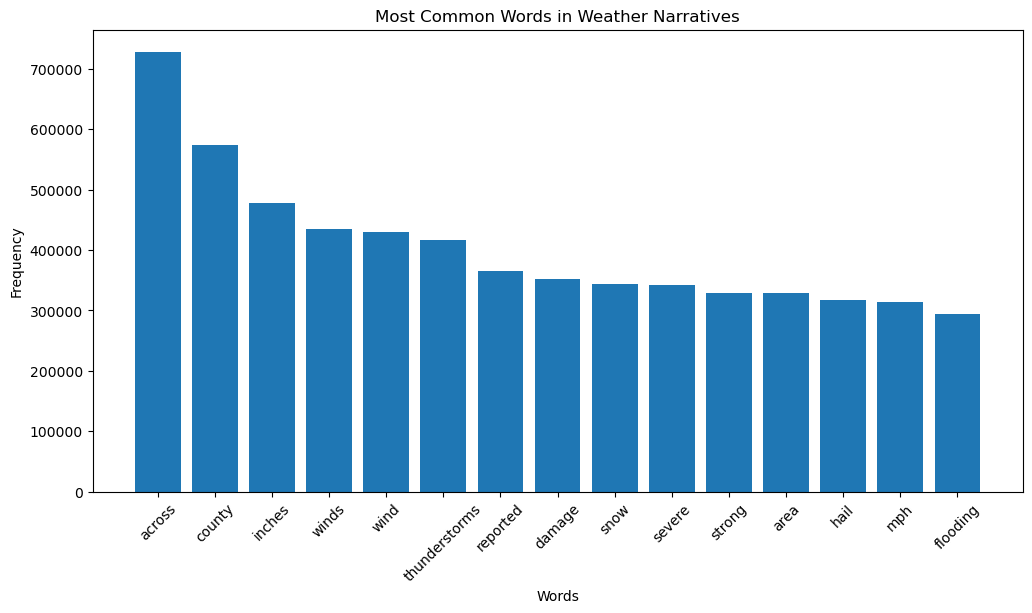

In [37]:
# Plot most common words
plt.figure(figsize=(12,6))

plt.bar(common_words["word"], common_words["frequency"])

plt.title("Most Common Words in Weather Narratives")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.show()

**Interpretation of the Most Common Words**

The most common words are strongly related to weather reports and storm impacts. Terms such as "winds", "thunderstorms", "damage", "hail", and "flooding" appear very frequently, showing that the narratives mainly describe severe weather conditions and their consequences.

Words like "inches" and "mph" also appear often, indicating that many reports include numerical measurements such as rainfall amounts and wind speeds. This confirms that the text contains useful information for further NLP and machine learning analysis.